# Quant Finance Project
### Group 2: Nomunbileg Sukhbold, Ryusei Nakano

### Selected Paper:
- Value-Glamour and Accruals Mispricing: One Anomaly or Two?
- Author(s): Hemang Desai, Shivaram Rajgopal and Mohan Venkatachalam

We start with the universe of firms listed on the NYSE, Amex, and NASDAQ markets for which requisite financial and return data are available on Compustat and CRSP.

In [1]:
!pip install wrds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.5 MB/s eta 0:00:00


In [2]:
!pip install pyarrow

In [ ]:
import os
import pandas as pd
from datetime import datetime
import getpass
import wrds
import numpy as np
from google.colab import drive
drive.mount("/content/drive")

username = input("Enter your WRDS username: ")
password = getpass.getpass("Enter your WRDS password: ")
db = wrds.Connection(wrds_username=username, password=password)

In [4]:
import wrds
import pandas as pd
import numpy as np


# -----------------------------------
# 1) COMPUSTAT ANNUAL FUNDAMENTALS
# -----------------------------------
comp = db.raw_sql("""
    select
        gvkey,
        datadate,
        fyear,
        fyr,
        sich,
        cusip,
        sale,
        at,
        act,
        che,
        lct,
        dlc,
        txp,
        dp,
        oiadp,
        ceq,
        capx,
        seq,
        pstkrv,
        pstkl,
        pstk
    from comp.funda
    where indfmt = 'INDL'
      and datafmt = 'STD'
      and popsrc = 'D'
      and consol = 'C'
      and datadate >= '1973-01-01'
      and datadate <= '1997-12-31'
""", date_cols=["datadate"])

# Basic paper-style screens
comp["sich"] = pd.to_numeric(comp["sich"], errors="coerce")
comp["sale"] = pd.to_numeric(comp["sale"], errors="coerce")

# Exclude financials
comp = comp[
    comp["sich"].isna() |
    (comp["sich"] < 6000) |
    (comp["sich"] > 6999)
]

# Exclude firms with sales under $1m (Compustat annual items are usually in $ millions)
comp = comp[(comp["sale"].isna()) | (comp["sale"] >= 1)]

# Sort for lag calculations
comp = comp.sort_values(["gvkey", "datadate"]).reset_index(drop=True)

# -----------------------------------
# 2) CCM LINK TABLE
# -----------------------------------
ccm = db.raw_sql("""
    select
        gvkey,
        lpermno as permno,
        lpermco as permco,
        linktype,
        linkprim,
        linkdt,
        linkenddt
    from crsp.ccmxpf_linktable
    where lpermno is not null
      and linktype in ('LU', 'LC')
      and linkprim in ('P', 'C')
""", date_cols=["linkdt", "linkenddt"])

ccm["linkenddt"] = ccm["linkenddt"].fillna(pd.Timestamp("today").normalize())

# -----------------------------------
# 3) CRSP MONTHLY STOCK DATA
# -----------------------------------
crsp_m = db.raw_sql("""
    select
        a.permno,
        a.permco,
        a.date,
        a.ret,
        d.dlret,
        a.prc,
        a.shrout,
        b.exchcd,
        b.shrcd
    from crsp.msf as a

    left join crsp.msenames as b
      on a.permno = b.permno
     and b.namedt <= a.date
     and a.date <= b.nameendt

    left join crsp.msedelist as d
      on a.permno = d.permno
     and date_trunc('month', a.date) = date_trunc('month', d.dlstdt)

    where a.date >= '1973-01-01'
      and a.date <= '1997-12-31'
""", date_cols=["date"])

# Keep common shares on NYSE/AMEX/NASDAQ
crsp_m = crsp_m[crsp_m["shrcd"].isin([10, 11])]
crsp_m = crsp_m[crsp_m["exchcd"].isin([1, 2, 3])]

# Convert to numeric
for col in ["ret", "dlret", "prc", "shrout"]:
    crsp_m[col] = pd.to_numeric(crsp_m[col], errors="coerce")

# Market equity in $ millions
crsp_m["me"] = (crsp_m["prc"].abs() * crsp_m["shrout"]) / 1000.0

# Delisting-adjusted returns
def combine_ret(ret, dlret):
    if pd.isna(ret) and pd.isna(dlret):
        return np.nan
    if pd.isna(ret):
        return dlret
    if pd.isna(dlret):
        return ret
    return (1 + ret) * (1 + dlret) - 1

crsp_m["retadj"] = [
    combine_ret(r, d) for r, d in zip(crsp_m["ret"], crsp_m["dlret"])
]

# Month-end date helper
crsp_m["month_end"] = crsp_m["date"] + pd.offsets.MonthEnd(0)

# -----------------------------------
# SANITY CHECK
# -----------------------------------
print("Compustat shape:", comp.shape)
print("CCM shape:", ccm.shape)
print("CRSP monthly shape:", crsp_m.shape)

Compustat shape: (192330, 21)
CCM shape: (33324, 7)
CRSP monthly shape: (1695860, 12)


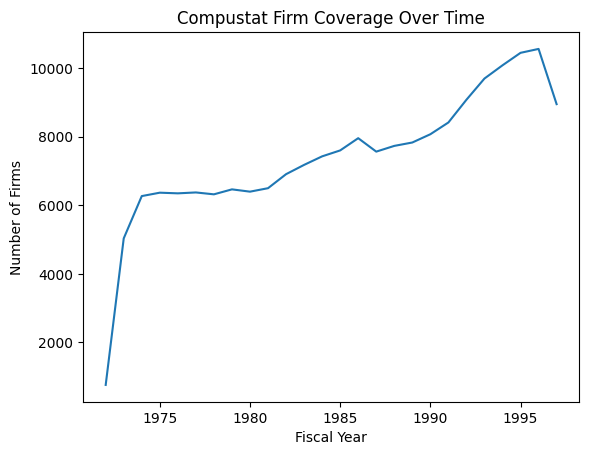

In [5]:
import matplotlib.pyplot as plt

coverage = comp.groupby("fyear")["gvkey"].nunique()

plt.figure()
coverage.plot()
plt.title("Compustat Firm Coverage Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Firms")
plt.show()

In [6]:
comp = comp.dropna(subset=[
    "act",
    "che",
    "lct",
    "dlc",
    "txp",
    "dp",
    "oiadp",
    "at",
    "sale"
])

In [7]:
comp.shape

(148891, 21)

In [8]:
winsor_vars = [
    "sale",
    "at",
    "act",
    "che",
    "lct",
    "dlc",
    "txp",
    "dp",
    "oiadp"
]

for col in winsor_vars:

    comp[col] = comp.groupby("fyear")[col].transform(
        lambda x: x.clip(x.quantile(0.01), x.quantile(0.99))
    )

In [9]:
# sort first
comp = comp.sort_values(["gvkey","datadate"])

# lagged variables
for v in ["act","che","lct","dlc","txp","at","sale"]:
    comp["lag_"+v] = comp.groupby("gvkey")[v].shift(1)

comp["lag2_sale"] = comp.groupby("gvkey")["sale"].shift(2)
comp["lag3_sale"] = comp.groupby("gvkey")["sale"].shift(3)

# average assets
comp["avg_at"] = (comp["at"] + comp["lag_at"]) / 2

# accruals (balance sheet approach)
# Accruals = (ΔCA - ΔCash) - (ΔCL - ΔSTD - ΔTP) - Dep
d_act = comp["act"] - comp["lag_act"]
d_che = comp["che"] - comp["lag_che"]
d_lct = comp["lct"] - comp["lag_lct"]
d_dlc = comp["dlc"] - comp["lag_dlc"]
d_txp = comp["txp"] - comp["lag_txp"]

comp["accruals_raw"] = (d_act - d_che) - (d_lct - d_dlc - d_txp) - comp["dp"]

# scaled accruals
comp["acc"] = comp["accruals_raw"] / comp["avg_at"]

# working capital accruals
comp["wc_accruals"] = comp["accruals_raw"] + comp["dp"]

# cash flow from operations
comp["cfo"] = comp["oiadp"] + comp["dp"] - comp["wc_accruals"]

# sales growth
g1 = comp["sale"] / comp["lag_sale"] - 1
g2 = comp["lag_sale"] / comp["lag2_sale"] - 1
g3 = comp["lag2_sale"] / comp["lag3_sale"] - 1

comp["sg"] = pd.concat([g1, g2, g3], axis=1).mean(axis=1, skipna=True)

In [10]:
# Signal timing
comp["form_date"] = comp["datadate"] + pd.DateOffset(months=4)
comp["form_date"] = comp["form_date"] + pd.offsets.MonthEnd(0)

In [11]:
# merge Link
comp_linked = comp.merge(ccm,on="gvkey",how="left")

comp_linked = comp_linked[
    (comp_linked["form_date"] >= comp_linked["linkdt"]) &
    (comp_linked["form_date"] <= comp_linked["linkenddt"])
]

In [12]:
# merge market equity
crsp_form = crsp_m[["permno","month_end","me"]].rename(
    columns={"month_end":"form_date"}
)

panel = comp_linked.merge(
    crsp_form,
    on=["permno","form_date"],
    how="left"
)

In [13]:
# Build anomaly signal
panel["ep"] = panel["oiadp"] / panel["me"]
panel["cp"] = (panel["oiadp"] + panel["dp"]) / panel["me"]
panel["cfop"] = panel["cfo"] / panel["me"]
panel["cfo_ta"] = panel["cfo"] / panel["avg_at"]

panel = panel[panel["ceq"] > 0]
panel["bm"] = panel["ceq"] / panel["me"]

panel["ap"] = panel["accruals_raw"] / panel["me"]

In [14]:
panel.shape

(106172, 50)

In [15]:
panel = panel.drop(panel[panel["sg"] > 48].index)
panel = panel.drop(panel[panel["sg"] <= -0.7].index)

In [16]:
panel.shape

(106136, 50)

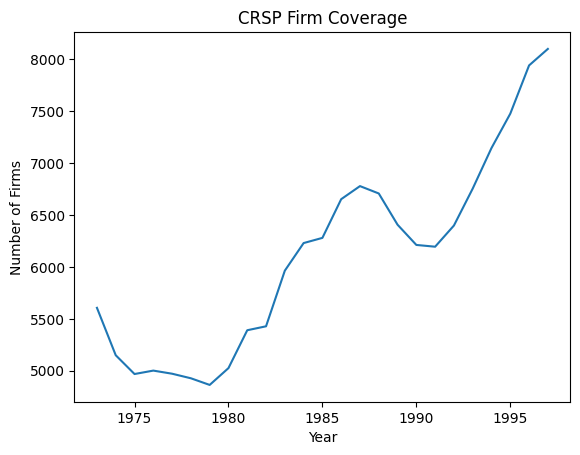

In [17]:
plt.figure()
crsp_m.groupby(crsp_m["date"].dt.year)["permno"].nunique().plot()
plt.title("CRSP Firm Coverage")
plt.xlabel("Year")
plt.ylabel("Number of Firms")
plt.show()

## Overall Descriptive stats:

In [18]:
vars_panelA = [
    "acc",
    "ap",
    "bm",
    "sg",
    "ep",
    "cp",
    "cfop",
    "cfo_ta"
]

panelA = panel[vars_panelA].describe().T

panelA = panelA[["mean","std","50%","min","max"]]

panelA = panelA.rename(columns={
    "mean":"Mean",
    "std":"Std Dev",
    "50%":"Median",
    "min":"Min",
    "max":"Max"
})

panelA.index = [
    "ACC",
    "A/P",
    "B/M",
    "SG",
    "E/P",
    "C/P",
    "CFO/P",
    "CFO/TA"
]

panelA = panelA.round(2)

print(panelA)

        Mean  Std Dev  Median    Min    Max
ACC    -0.02     0.12   -0.03  -1.58   4.27
A/P    -0.09     0.59   -0.03 -65.38  25.32
B/M     0.87     0.85    0.66    0.0  36.61
SG      0.26     0.85    0.13   -0.7  47.72
E/P     0.11     0.45    0.11 -86.11   6.85
C/P     0.21     0.45    0.17 -77.44  19.68
CFO/P    0.2     0.59    0.15 -56.21   65.5
CFO/TA   0.1     0.18    0.12  -4.16   6.57


In [19]:
panelB = panel[vars_panelA].corr()

panelB.index = [
    "ACC",
    "A/P",
    "B/M",
    "SG",
    "E/P",
    "C/P",
    "CFO/P",
    "CFO/TA"
]

panelB = panelB.round(2)
print(panelB)

         acc    ap    bm    sg    ep    cp  cfop  cfo_ta
ACC     1.00  0.45 -0.08  0.14  0.15  0.06 -0.33   -0.46
A/P     0.45  1.00 -0.22  0.06  0.39  0.17 -0.69   -0.19
B/M    -0.08 -0.22  1.00 -0.10  0.02  0.23  0.21   -0.04
SG      0.14  0.06 -0.10  1.00  0.01 -0.01 -0.05   -0.09
E/P     0.15  0.39  0.02  0.01  1.00  0.89  0.40    0.21
C/P     0.06  0.17  0.23 -0.01  0.89  1.00  0.54    0.22
CFO/P  -0.33 -0.69  0.21 -0.05  0.40  0.54  1.00    0.36
CFO/TA -0.46 -0.19 -0.04 -0.09  0.21  0.22  0.36    1.00


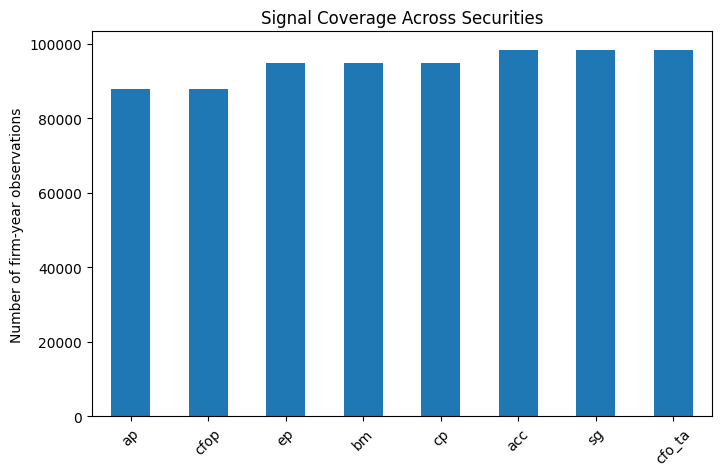

In [20]:
coverage = panel[vars_panelA].notna().sum().sort_values()

plt.figure(figsize=(8,5))
coverage.plot(kind="bar")
plt.ylabel("Number of firm-year observations")
plt.title("Signal Coverage Across Securities")
plt.xticks(rotation=45)
plt.show()

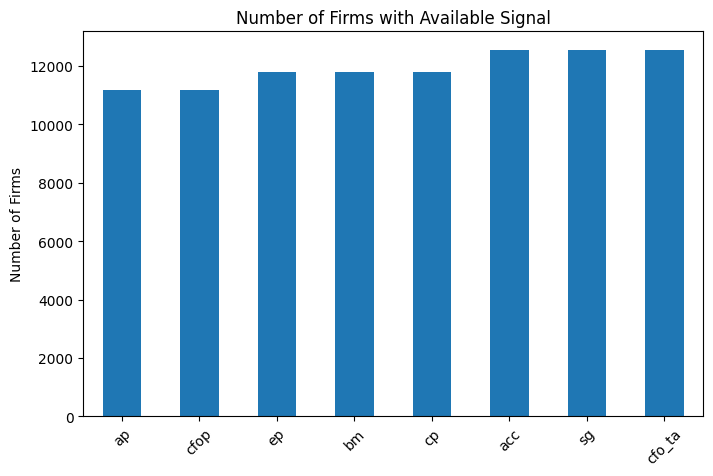

In [21]:
# count unique firms with each signal
firm_counts = panel[vars_panelA].notna().groupby(panel["gvkey"]).any().sum()

plt.figure(figsize=(8,5))
firm_counts.sort_values().plot(kind="bar")

plt.ylabel("Number of Firms")
plt.title("Number of Firms with Available Signal")
plt.xticks(rotation=45)

plt.show()

## Outlier and stability analysis

In [22]:
panel[vars_panelA].isna().sum()

,0
acc,7722
ap,18205
bm,11266
sg,7722
ep,11266
cp,11266
cfop,18205
cfo_ta,7722


In [23]:
panel = panel.dropna(subset=vars_panelA)

In [24]:
panel.shape

(87931, 50)

In [25]:
signals = ["acc","ap","bm","sg","ep","cp","cfop","cfo_ta"]

panel[signals].describe(percentiles=[0.01,0.05,0.95,0.99])

,acc,ap,bm,sg,ep,cp,cfop,cfo_ta
count,87931.0,87931.0,87931.0,87931.0,87931.0,87931.0,87931.0,87931.0
mean,-0.020794,-0.092026,0.870075,0.250289,0.110599,0.209801,0.202625,0.102231
std,0.123284,0.585823,0.834934,0.824234,0.463058,0.453508,0.588872,0.170192
min,-1.584073,-65.384868,0.000184,-0.69989,-86.112554,-77.437229,-56.207792,-3.045469
1%,-0.350566,-1.680009,0.047621,-0.258967,-0.940745,-0.618184,-0.71073,-0.490134
5%,-0.18853,-0.553493,0.132927,-0.105123,-0.236298,-0.12123,-0.182312,-0.178588
50%,-0.028594,-0.030548,0.667143,0.129317,0.114384,0.174941,0.146248,0.120026
95%,0.172001,0.22934,2.239299,0.846695,0.472059,0.67058,0.75232,0.318464
99%,0.359485,0.677744,3.758722,2.316416,0.802448,1.174732,1.631023,0.464842
max,3.028711,25.320599,36.608367,47.72472,6.851055,19.67874,65.49801,1.703153


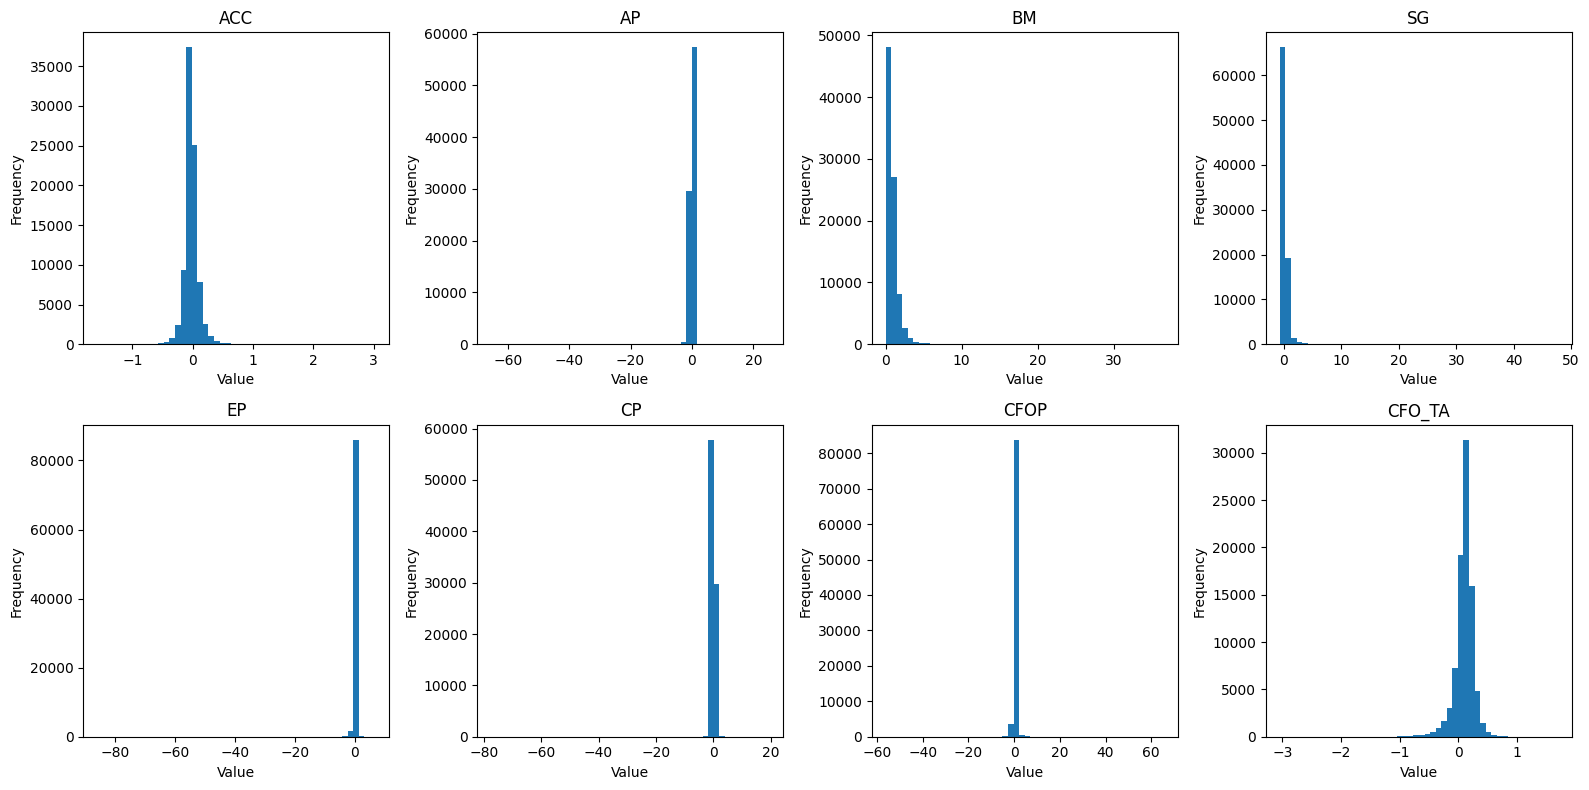

In [26]:
import matplotlib.pyplot as plt

signals = ["acc","ap","bm","sg","ep","cp","cfop","cfo_ta"]

fig, axes = plt.subplots(2, 4, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(signals):
    axes[i].hist(panel[col].dropna(), bins=50)
    axes[i].set_title(col.upper())
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

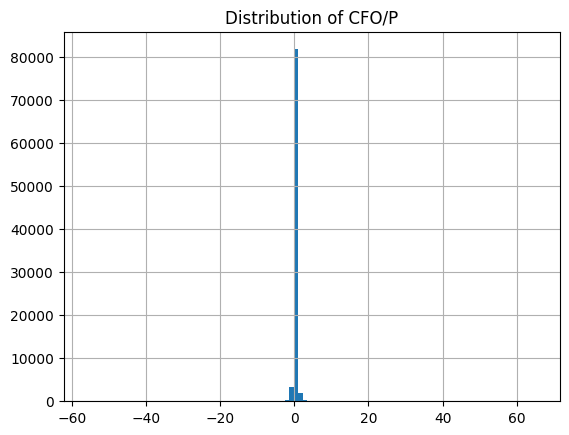

In [27]:
import matplotlib.pyplot as plt

panel["cfop"].hist(bins=100)
plt.title("Distribution of CFO/P")
plt.show()

Largest values for each signal

In [28]:
signals = ["acc","ap","bm","sg","ep","cp","cfop","cfo_ta"]

for col in signals:
    print(f"\nTop 5 values for {col.upper()}")
    print(panel.nlargest(5, col)[["gvkey","fyear", col]])

In [29]:
for col in signals:
    print(f"\nSmallest 5 values for {col.upper()}")
    print(panel.nsmallest(5, col)[["gvkey","fyear", col]])

**Winsorize signals: remove extreme values**

In [30]:
for col in signals:

    lower = panel[col].quantile(0.00004)
    upper = panel[col].quantile(0.99996)

    panel[col] = panel[col].clip(lower, upper)

**Summary statistics after cleaning:**

In [31]:
panel_clean = panel[signals].describe().T

panel_clean = panel_clean[["mean","std","50%","min","max"]]

panel_clean = panel_clean.rename(columns={
    "mean":"Mean",
    "std":"Std Dev",
    "50%":"Median",
    "min":"Min",
    "max":"Max"
})

panel_clean.index = [
    "ACC",
    "A/P",
    "B/M",
    "SG",
    "E/P",
    "C/P",
    "CFO/P",
    "CFO/TA"
]

panel_clean = panel_clean.round(2)

print(panel_clean)

        Mean  Std Dev  Median    Min    Max
ACC    -0.02     0.12   -0.03  -1.25   1.41
A/P    -0.09     0.53   -0.03 -25.62  11.85
B/M     0.87     0.83    0.67    0.0  24.09
SG      0.25     0.81    0.13  -0.67  37.74
E/P     0.11     0.36    0.11 -16.11   5.38
C/P     0.21     0.36    0.17 -11.93   8.16
CFO/P    0.2      0.5    0.15  -14.4  16.61
CFO/TA   0.1     0.17    0.12  -2.12   1.43


In [32]:
panelB_clean = panel[signals].corr()

panelB_clean.index = [
    "ACC",
    "A/P",
    "B/M",
    "SG",
    "E/P",
    "C/P",
    "CFO/P",
    "CFO/TA"
]

panelB_clean = panelB_clean.round(2)
print(panelB_clean)

         acc    ap    bm    sg    ep    cp  cfop  cfo_ta
ACC     1.00  0.50 -0.08  0.16  0.19  0.07 -0.39   -0.48
A/P     0.50  1.00 -0.24  0.07  0.41  0.11 -0.72   -0.21
B/M    -0.08 -0.24  1.00 -0.10  0.03  0.28  0.27   -0.04
SG      0.16  0.07 -0.10  1.00  0.01 -0.01 -0.07   -0.09
E/P     0.19  0.41  0.03  0.01  1.00  0.84  0.32    0.27
C/P     0.07  0.11  0.28 -0.01  0.84  1.00  0.51    0.27
CFO/P  -0.39 -0.72  0.27 -0.07  0.32  0.51  1.00    0.42
CFO/TA -0.48 -0.21 -0.04 -0.09  0.27  0.27  0.42    1.00


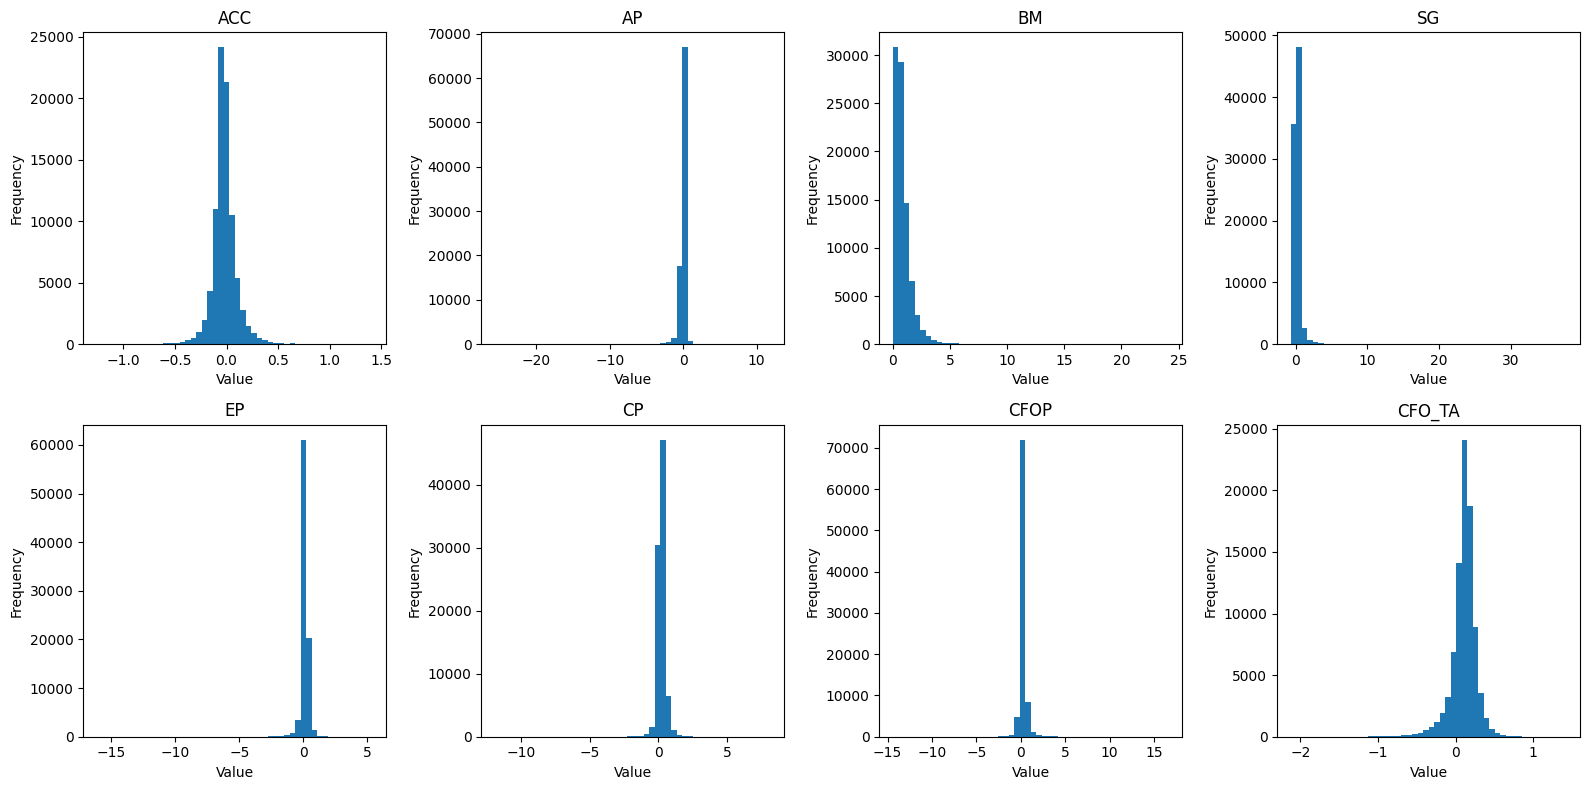

In [33]:
import matplotlib.pyplot as plt

signals = ["acc","ap","bm","sg","ep","cp","cfop","cfo_ta"]

fig, axes = plt.subplots(2, 4, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(signals):
    axes[i].hist(panel[col].dropna(), bins=50)
    axes[i].set_title(col.upper())
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

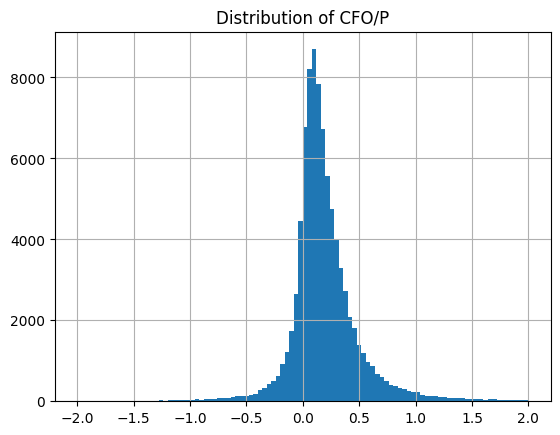

In [34]:
import matplotlib.pyplot as plt

panel["cfop"].hist(bins=100, range=(-2,2))
plt.title("Distribution of CFO/P")
plt.show()

Final panel shape: 87263 firm-year observations

In [35]:
panel.shape

(87931, 50)

**Signal stability over time:**

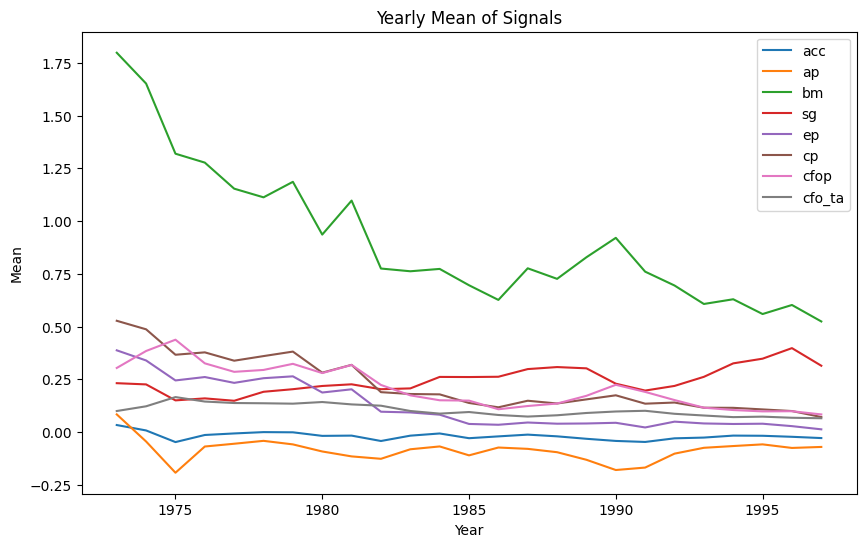

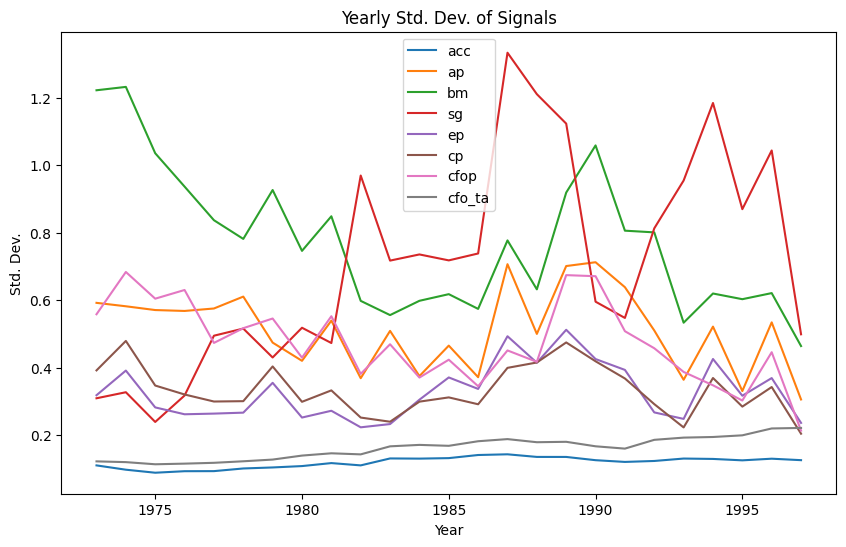

In [36]:
yearly_mean = panel.groupby("fyear")[signals].mean()
yearly_std = panel.groupby("fyear")[signals].std()

yearly_mean.plot(figsize=(10,6))
plt.title("Yearly Mean of Signals")
plt.xlabel("Year")
plt.ylabel("Mean")
plt.show()

yearly_std.plot(figsize=(10,6))
plt.title("Yearly Std. Dev. of Signals")
plt.xlabel("Year")
plt.ylabel("Std. Dev.")
plt.show()

**Coverage stability:**

<Axes: xlabel='fyear'>

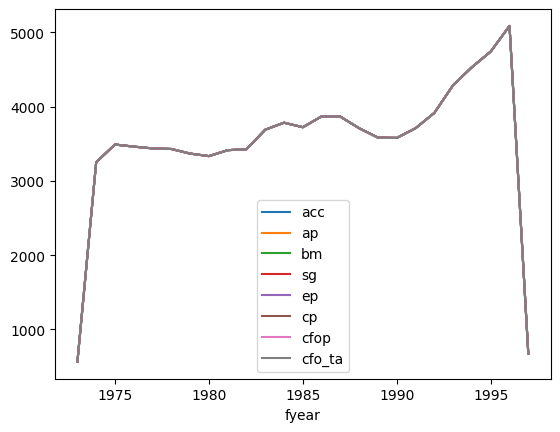

In [37]:
panel.groupby("fyear")[signals].count().plot()

**Signal Coverage over time**

<Figure size 640x480 with 0 Axes>

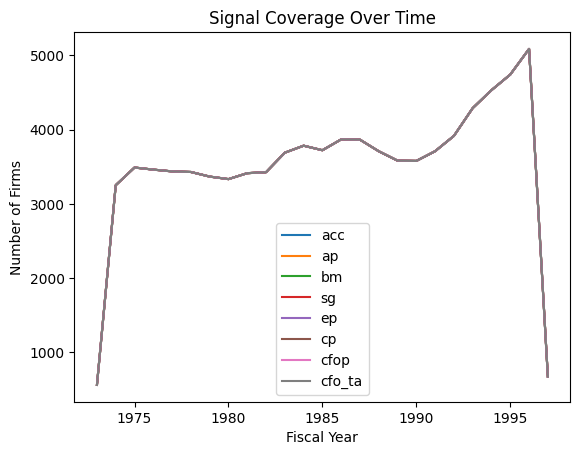

In [38]:
signal_cov = panel.groupby("fyear")[signals].count()

plt.figure()
signal_cov.plot()
plt.title("Signal Coverage Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Firms")
plt.show()

## Cross-sectional descriptive statistics computed at each date and summarized over time

In [39]:
vars_cs = [
    "cp",
    "cfop",
    "cfo_ta"
]

In [40]:
cs_stats = (
    panel.groupby("fyear")[vars_cs]
    .agg(["mean", "std", "median", "min", "max"])
)
cs_stats

cp                                               cfop            \
           mean       std    median        min       max      mean       std   
fyear                                                                          
1973   0.527376  0.392034  0.457788  -0.438499   3.72366  0.303746  0.558346   
1974   0.486937  0.479314  0.422288  -2.499635  8.163746  0.384201  0.683607   
1975   0.366372   0.34716  0.329054  -1.796306  8.163746  0.437669  0.604498   
1976   0.377673  0.320665  0.339894  -1.810966  6.097311  0.325638  0.630234   
1977    0.33815  0.299822  0.315109  -2.959464  4.630705  0.285348  0.473449   
1978   0.359997  0.300848  0.327491  -2.923447  5.236822  0.294321  0.517087   
1979   0.381329  0.403759  0.343011  -6.895028  7.769943  0.323301  0.545723   
1980   0.281415  0.298979  0.241906  -2.004323  4.151875  0.279493  0.429796   
1981   0.318454  0.332808  0.282037  -1.971258  4.885186  0.318095  0.552506   
1982   0.188998  0.252287  0.158488  -1.790865  4.208618  0.223229  0.381761   
1983   0.180274  0.239955  0.161695  -1.817842   3.74064  0.173868  0.469426   
1984   0.178568  0.299448  0.172637  -3.808595  3.025059  0.150566  0.370776   
1985   0.137758  0.312039  0.134679  -5.948701  3.046986  0.148919  0.423707   
1986   0.117206  0.291685  0.120123  -7.485798  4.308563    0.1079  0.345048   
1987    0.14837  0.399561  0.154171 -11.932652  6.707406  0.123371  0.451164   
1988   0.135351  0.415424  0.147647  -8.175161  7.450366  0.135122  0.417382   
1989   0.154791  0.474859  0.153376 -11.932652  8.163746  0.171687  0.674263   
1990   0.174136  0.418999  0.157052  -6.821776  4.857648  0.223896  0.671055   
1991   0.134412  0.368063  0.125287   -5.07818  8.163746  0.190192  0.508151   
1992    0.13982    0.2921  0.124748  -5.068164  6.107642   0.15159  0.457638   
1993   0.115285  0.223083   0.11529  -2.976164  3.602072  0.115409  0.387487   
1994   0.114755  0.369494   0.12265 -11.932652  4.493191  0.104244  0.347912   
1995   0.107237  0.284748  0.103738   -8.09665  5.146853  0.097891  0.302759   
1996   0.099523  0.342723  0.106076 -11.932652  4.532632  0.098638  0.445882   
1997   0.071123   0.20445  0.084694  -2.101488  1.099012  0.083474  0.213631   

                                         cfo_ta                                \
         median        min        max      mean       std    median       min   
fyear                                                                           
1973   0.261046  -2.599849   5.036514  0.099597   0.12251  0.098608 -0.731133   
1974   0.288741  -9.278186  13.234667  0.122012  0.120265   0.11561 -0.932936   
1975   0.340405  -5.912834  15.003488  0.165678  0.113913  0.155333 -0.682283   
1976   0.283181 -14.401737   6.993211  0.144511  0.115792  0.140899 -0.653964   
1977   0.255061    -5.3765  16.608573  0.137549  0.118235  0.136204 -1.129999   
1978   0.250271  -7.370054  16.608573  0.136365  0.122778  0.134479 -0.935122   
1979   0.254393  -6.150718   9.555345  0.134457  0.127836  0.133833 -1.217551   
1980   0.214023  -3.732321   7.683596  0.142272  0.139643  0.141545 -1.060185   
1981   0.238952  -2.410959      15.18  0.130975   0.14643  0.137465 -1.289689   
1982   0.165672  -2.943956   5.223536  0.124851  0.143242  0.134695 -1.276444   
1983   0.144829 -11.555045  16.608573  0.099756   0.16706  0.124997  -2.12376   
1984   0.131022  -3.755273   4.745023  0.087299  0.171323  0.113599  -1.29733   
1985   0.116956  -7.157514  11.864304  0.094842  0.168581  0.114016 -0.971795   
1986   0.095046  -4.669204   4.882978  0.080812   0.18216  0.101791  -2.12376   
1987   0.111914  -8.252742   7.909577  0.073338  0.188454  0.098912  -1.82523   
1988   0.112759  -3.763578   7.477734   0.07944  0.179236  0.105189 -1.364691   
1989   0.130319 -12.217625  16.608573  0.090321  0.180468  0.110321 -1.601582   
1990   0.143928  -8.282655  13.792611  0.097357  0.167166  0.117811 -1.268208   
1991   0.122655  -7.372274   8.691856  0.100719  0.160288    0.1158 -1.

In [41]:
summary_over_time = cs_stats.mean()
summary_over_time = summary_over_time.unstack().round(2)
print(summary_over_time)

        mean   std  median   min   max
cp      0.23  0.33    0.21 -5.21  5.26
cfop    0.21  0.47    0.17 -7.19  9.76
cfo_ta   0.1  0.16    0.12 -1.43  1.04


## Pull WRDS prebuild signal and compare:

In [42]:
'''
wrds_sig = db.raw_sql("""
    select
        *
    from wrdsapps_backtest_plus.signals_raw_plus
    where fdate >= '1973-01-01'
      and fdate <= '1997-12-31'
""", date_cols=["date"])

print(wrds_sig.shape)
wrds_sig.head()
'''

'\nwrds_sig = db.raw_sql("""\n    select\n        *\n    from wrdsapps_backtest_plus.signals_raw_plus\n    where fdate >= \'1973-01-01\'\n      and fdate <= \'1997-12-31\'\n""", date_cols=["date"])\n\nprint(wrds_sig.shape)\nwrds_sig.head()\n'

In [43]:
'''
os.makedirs("/content/drive/MyDrive/Colab Notebooks/Quant Finance/Quant Finance Project", exist_ok=True)

# Save Parquet
wrds_sig.to_parquet(
    "/content/drive/MyDrive/Colab Notebooks/Quant Finance/Quant Finance Project/signals_1973to1997.parquet",
    engine="pyarrow",
    compression="snappy"
)
'''

'\nos.makedirs("/content/drive/MyDrive/Colab Notebooks/Quant Finance/Quant Finance Project", exist_ok=True)\n\n# Save Parquet\nwrds_sig.to_parquet(\n    "/content/drive/MyDrive/Colab Notebooks/Quant Finance/Quant Finance Project/signals_1973to1997.parquet",\n    engine="pyarrow",\n    compression="snappy"\n)\n'

In [44]:
signal = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/Quant Finance/Quant Finance Project/signals_1973to1997.parquet")

In [45]:
wrds_subset = signal[[
    "permno",
    "fdate",
    "absaccrual",
    "btm",
    "saleg",
    "pe",
    "cf_p",
    "cf"
]].copy()

wrds_signals = wrds_subset.rename(columns={
    "absaccrual": "acc_wrds",
    "btm": "bm_wrds",
    "saleg": "sg_wrds",
    "pe": "ep_wrds",          # keeping as requested
    "cf_p": "cfop_wrds",
    "cf": "cfo_ta_wrds"
})

wrds_signals["year"] = pd.to_datetime(wrds_signals["fdate"]).dt.year

wrds_signals = wrds_signals[[
    "permno",
    "fdate",
    "year",
    "acc_wrds",
    "bm_wrds",
    "sg_wrds",
    "ep_wrds",
    "cfop_wrds",
    "cfo_ta_wrds"
]].copy()

In [46]:
rep_signals = panel[[
    "permno",
    "gvkey",
    "fyear",
    "form_date",
    "acc",
    "bm",
    "sg",
    "ep",
    "cfop",
    "cfo_ta"
]].copy()

rep_signals = rep_signals.rename(columns={
    "acc": "acc_rep",
    "bm": "bm_rep",
    "sg": "sg_rep",
    "ep": "ep_rep",
    "cfop": "cfop_rep",
    "cfo_ta": "cfo_ta_rep"
})

rep_signals["form_date"] = pd.to_datetime(rep_signals["form_date"]) + pd.offsets.MonthEnd(0)

wrds_signals["fdate"] = pd.to_datetime(wrds_signals["fdate"]) + pd.offsets.MonthEnd(0)

In [47]:
compare_exact = rep_signals.merge(
    wrds_signals,
    left_on=["permno", "form_date"],
    right_on=["permno", "fdate"],
    how="inner"
)

print("Exact month match:", compare_exact.shape)

Exact month match: (86493, 18)


**Correlation and mean difference between WRDS signal vs Constructed Signal:**

In [48]:
compare = compare_exact.copy()   # or compare_ym / compare_yearly

pairs = [
    ("cfop_rep", "cfop_wrds"),
    ("cfo_ta_rep", "cfo_ta_wrds"),
    ("bm_rep", "bm_wrds"),
    ("sg_rep", "sg_wrds"),
    ("ep_rep", "ep_wrds"),
    ("acc_rep", "acc_wrds")
]

results = []

for rep_col, wrds_col in pairs:
    temp = compare[[rep_col, wrds_col]].dropna().copy()

    corr = temp[rep_col].corr(temp[wrds_col])
    mad = (temp[rep_col] - temp[wrds_col]).abs().mean()
    mean_diff = (temp[rep_col] - temp[wrds_col]).mean()

    results.append({
        "signal": rep_col.replace("_rep", ""),
        "n": len(temp),
        "correlation": corr,
        "mean_abs_diff": mad,
        "mean_diff": mean_diff
    })

comparison_table = pd.DataFrame(results)
comparison_table.round(2)

,signal,n,correlation,mean_abs_diff,mean_diff
0,cfop,86449,0.68,0.14,0.10
1,cfo_ta,86449,0.85,0.07,0.05
2,bm,85832,0.86,0.13,0.05
3,sg,85532,0.56,0.18,0.04
4,ep,86447,0.70,0.13,0.11
5,acc,85716,0.07,0.07,0.06


**Summary statistics comparison**

In [49]:
signals = ["cfop","cfo_ta","bm","sg","ep","acc",]

summary_list = []

for s in signals:

    rep = compare[f"{s}_rep"]
    wrds = compare[f"{s}_wrds"]

    summary_list.append({
        "signal": s,

        "rep_mean": rep.mean(),
        "wrds_mean": wrds.mean(),

        "rep_std": rep.std(),
        "wrds_std": wrds.std(),

        "rep_min": rep.min(),
        "wrds_min": wrds.min(),

        "rep_max": rep.max(),
        "wrds_max": wrds.max()
    })

summary_stats = pd.DataFrame(summary_list)

summary_stats

,signal,rep_mean,wrds_mean,rep_std,wrds_std,rep_min,wrds_min,rep_max,wrds_max
0,cfop,0.203885,0.102664,0.498036,0.352944,-14.401737,-7.668896,16.608573,12.018330
1,cfo_ta,0.102394,0.052592,0.168016,0.137368,-2.123760,-1.388571,1.425140,2.538936
2,bm,0.876380,0.826132,0.828680,0.664370,0.000560,0.014364,24.090287,6.146125
3,sg,0.246186,0.204695,0.806773,0.562529,-0.672282,-0.865655,37.739105,12.085106
4,ep,0.111828,0.003603,0.360775,0.314107,-16.111582,-8.128000,5.376941,3.001290
5,acc,-0.021345,-0.084814,0.121379,0.087843,-1.254668,-0.693555,1.410699,-0.000008


**Scatter plots (replicated vs WRDS)**

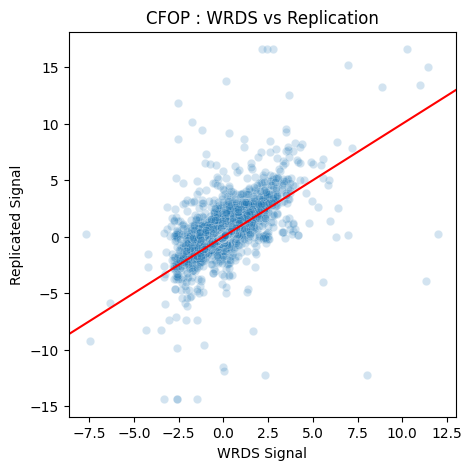

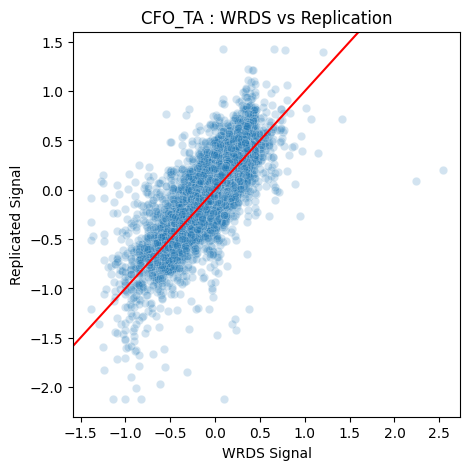

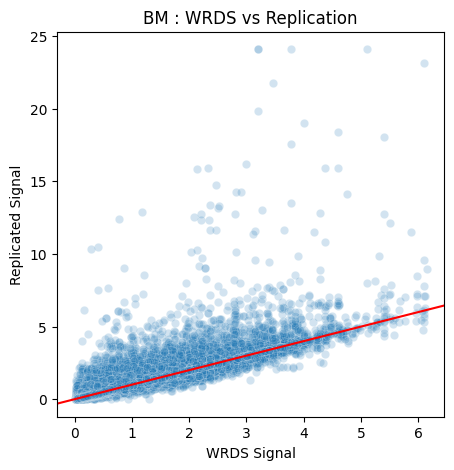

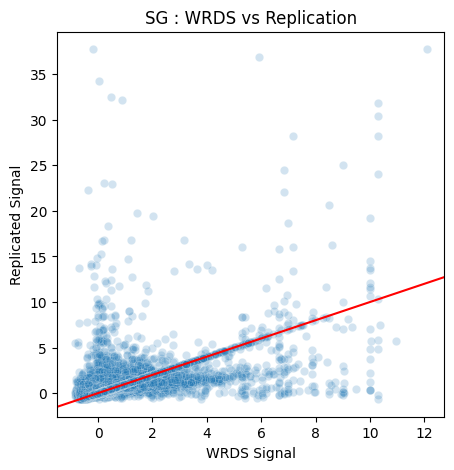

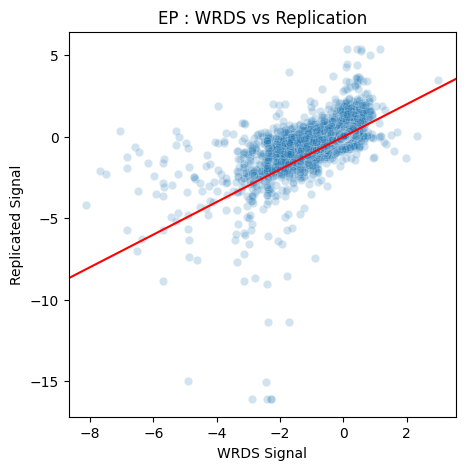

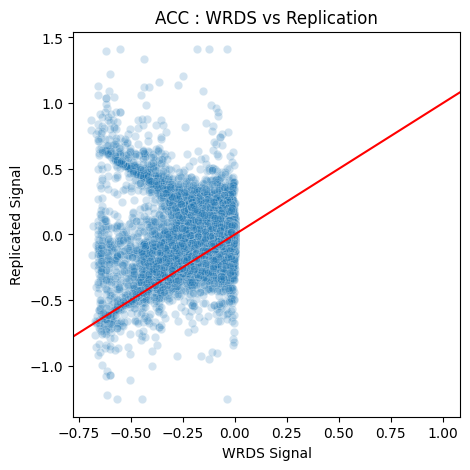

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

for s in signals:

    plt.figure(figsize=(5,5))

    sns.scatterplot(
        x=compare[f"{s}_wrds"],
        y=compare[f"{s}_rep"],
        alpha=0.2
    )

    plt.xlabel("WRDS Signal")
    plt.ylabel("Replicated Signal")

    plt.title(f"{s.upper()} : WRDS vs Replication")

    plt.axline((0,0),(1,1),color="red")

    plt.show()

**Distribution comparison**

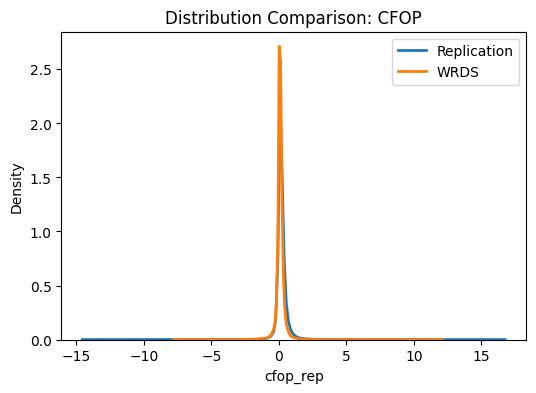

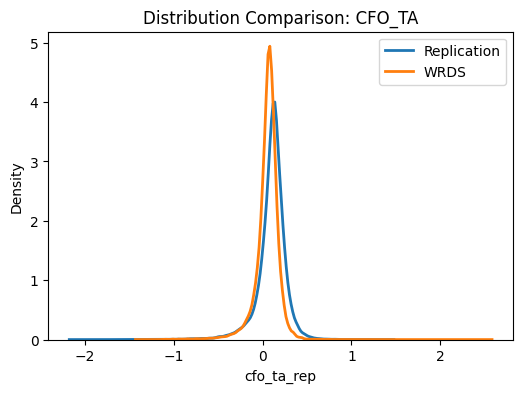

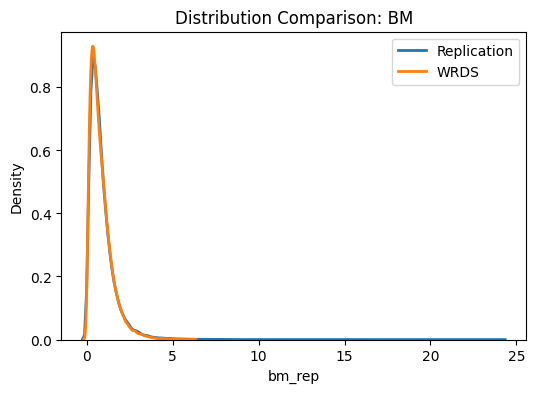

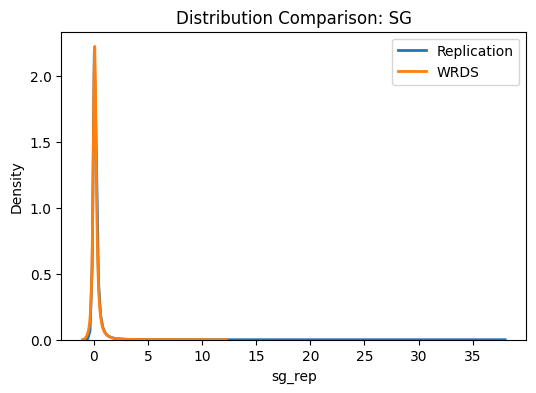

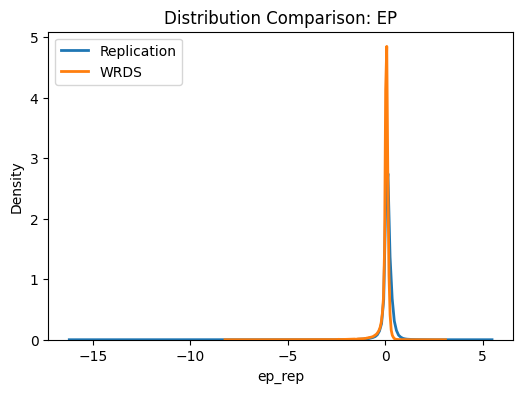

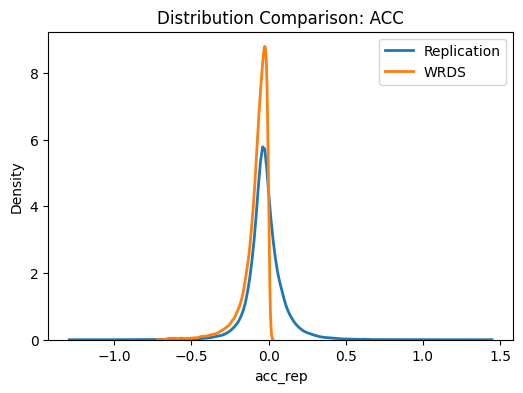

In [51]:
for s in signals:

    plt.figure(figsize=(6,4))

    sns.kdeplot(compare[f"{s}_rep"], label="Replication", linewidth=2)
    sns.kdeplot(compare[f"{s}_wrds"], label="WRDS", linewidth=2)

    plt.title(f"Distribution Comparison: {s.upper()}")

    plt.legend()
    plt.show()

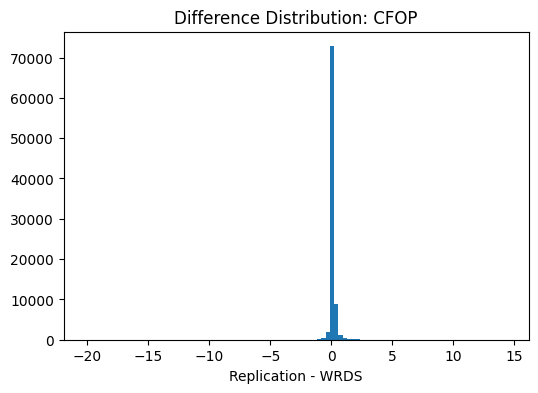

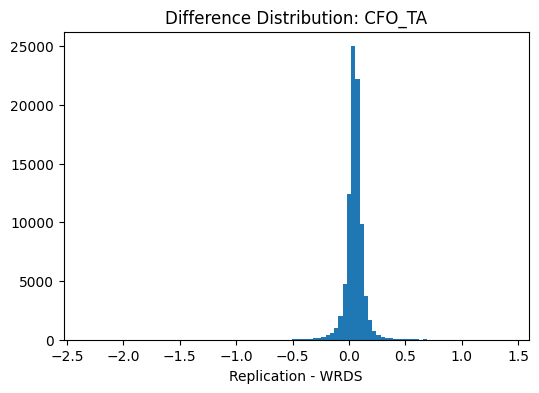

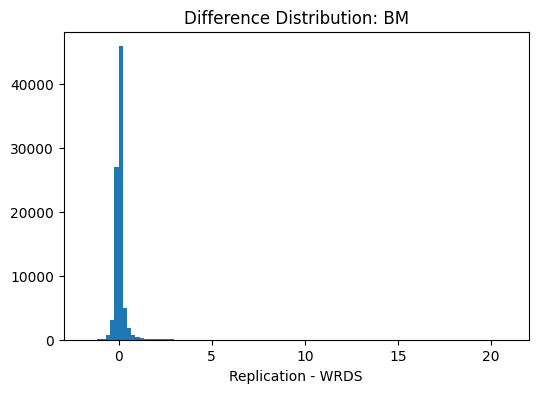

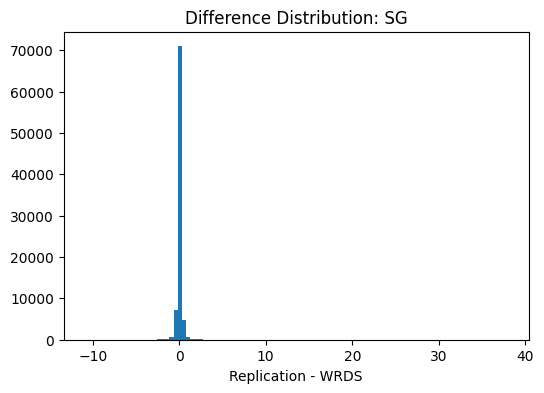

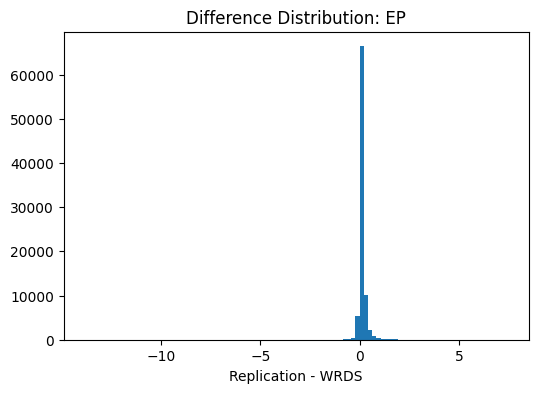

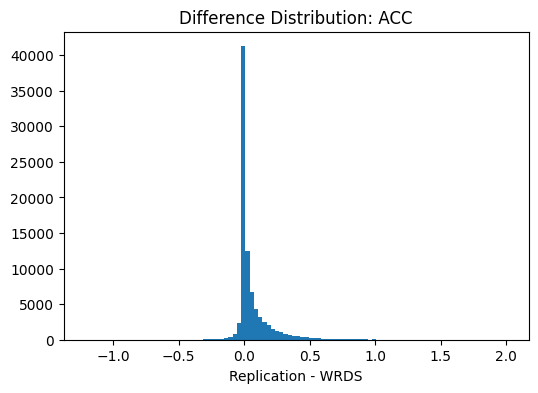

In [52]:
for s in signals:

    diff = compare[f"{s}_rep"] - compare[f"{s}_wrds"]

    plt.figure(figsize=(6,4))

    plt.hist(diff, bins=100)

    plt.title(f"Difference Distribution: {s.upper()}")

    plt.xlabel("Replication - WRDS")

    plt.show()

**Histogram of differences**

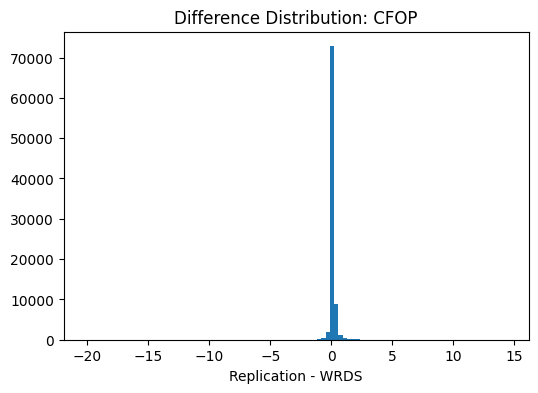

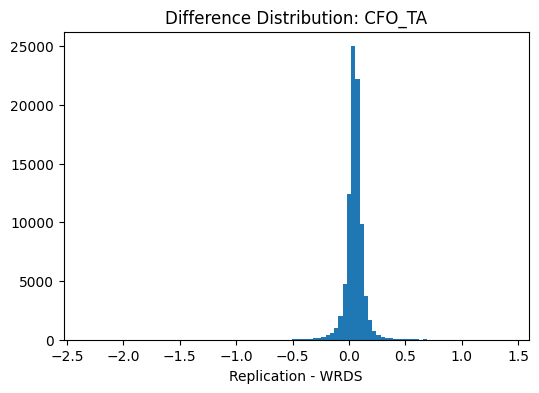

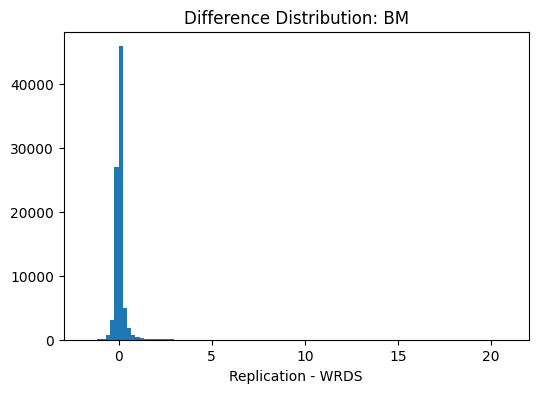

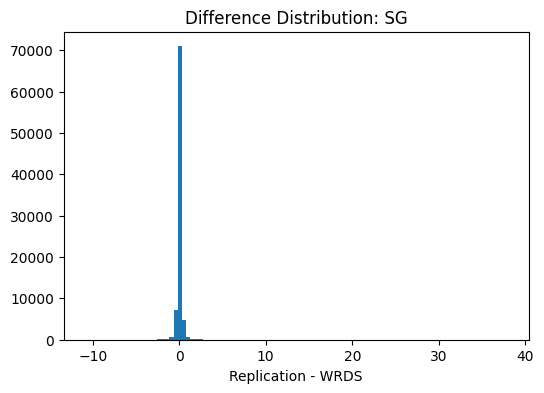

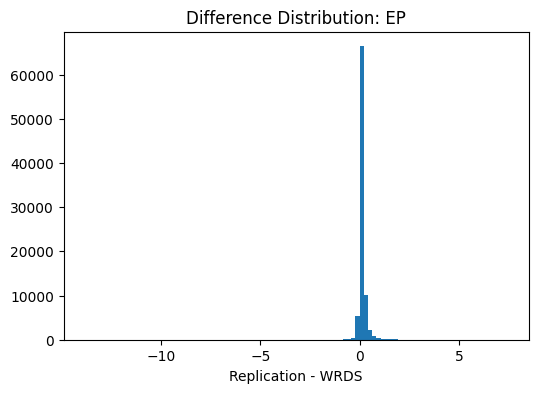

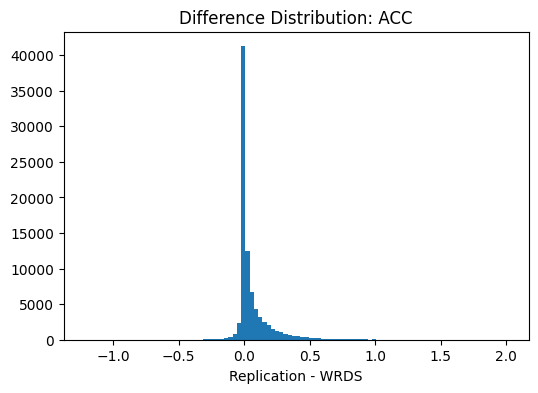

In [53]:
for s in signals:

    diff = compare[f"{s}_rep"] - compare[f"{s}_wrds"]

    plt.figure(figsize=(6,4))

    plt.hist(diff, bins=100)

    plt.title(f"Difference Distribution: {s.upper()}")

    plt.xlabel("Replication - WRDS")

    plt.show()

**Time-series comparison**

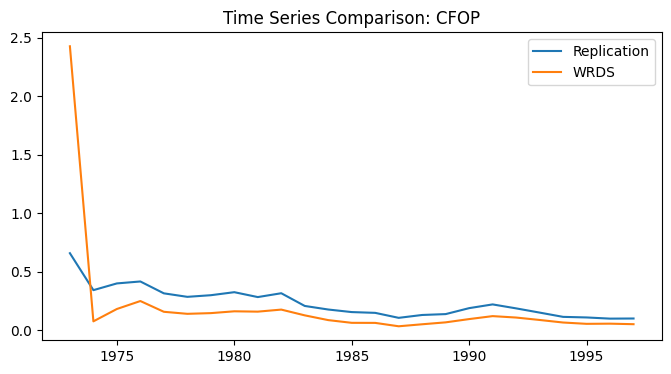

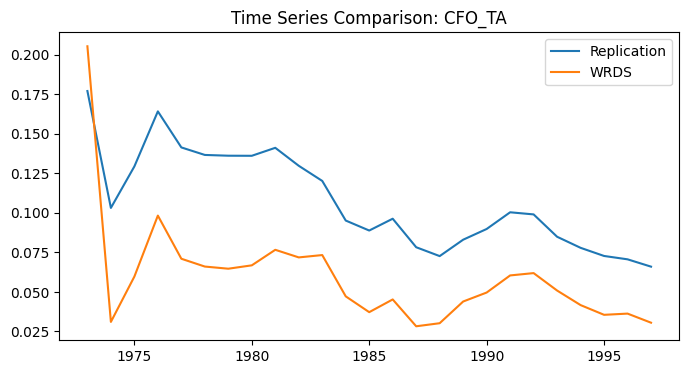

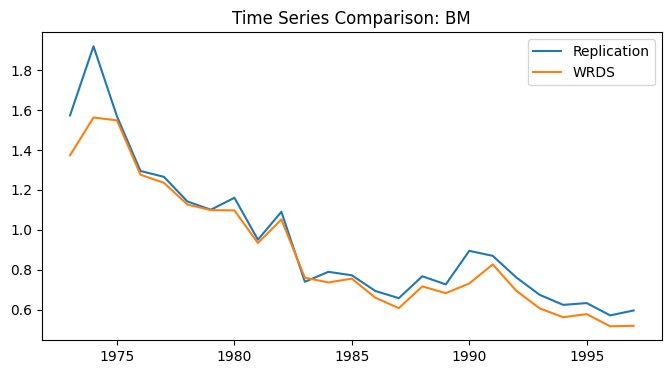

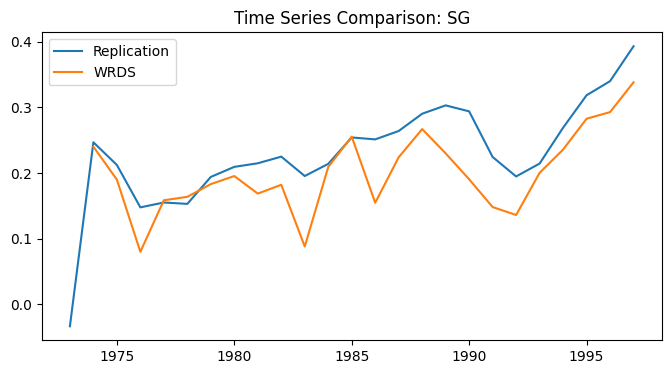

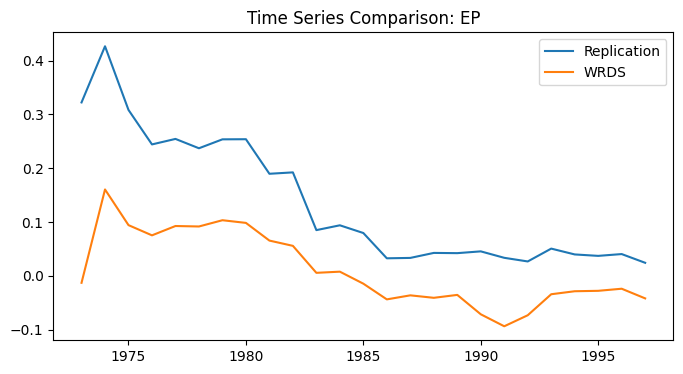

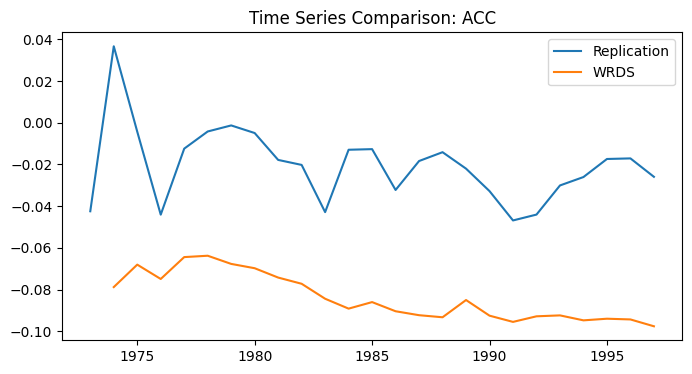

In [54]:
for s in signals:

    ts = compare.groupby("year")[[f"{s}_rep",f"{s}_wrds"]].mean()

    plt.figure(figsize=(8,4))

    plt.plot(ts.index, ts[f"{s}_rep"], label="Replication")
    plt.plot(ts.index, ts[f"{s}_wrds"], label="WRDS")

    plt.title(f"Time Series Comparison: {s.upper()}")

    plt.legend()

    plt.show()

## Build Monthly Backtest panel

In [55]:
panel_bt = panel.copy()

# holding months: month +1 through +12 after form_date
expanded = []
for h in range(1, 13):
    temp = panel_bt.copy()
    temp["hold_month"] = pd.to_datetime(temp["form_date"]) + pd.offsets.MonthEnd(h)
    expanded.append(temp)

signal_monthly = pd.concat(expanded, ignore_index=True)

print(signal_monthly.shape)
print(signal_monthly[["permno","form_date","hold_month","cfop"]].head())

In [56]:
import pandas as pd
import numpy as np

# ----------------------------
# 1) Clean dates in signal panel
# ----------------------------
signal_monthly = signal_monthly.copy()
signal_monthly["form_date"] = pd.to_datetime(signal_monthly["form_date"]) + pd.offsets.MonthEnd(0)
signal_monthly["hold_month"] = pd.to_datetime(signal_monthly["hold_month"]) + pd.offsets.MonthEnd(0)

# if a firm has multiple signals mapped to the same hold month, keep the most recent formation date
signal_monthly = (
    signal_monthly
    .sort_values(["permno", "hold_month", "form_date"])
    .drop_duplicates(subset=["permno", "hold_month"], keep="last")
)

print("Signal monthly after dedup:", signal_monthly.shape)
print(signal_monthly[["permno", "form_date", "hold_month", "cfop"]].head())

In [57]:
# ----------------------------
# 2) Prepare CRSP monthly returns
# ----------------------------
crsp_bt = crsp_m.copy()

crsp_bt["date"] = pd.to_datetime(crsp_bt["date"]) + pd.offsets.MonthEnd(0)
crsp_bt = crsp_bt.sort_values(["permno", "date"])

# lagged market equity for value-weighting at month t
crsp_bt["me_lag"] = crsp_bt.groupby("permno")["me"].shift(1)

# keep only needed columns
crsp_bt = crsp_bt[[
    "permno", "date", "retadj", "me", "me_lag", "exchcd", "shrcd"
]].copy()

print("CRSP backtest shape:", crsp_bt.shape)

CRSP backtest shape: (1695860, 7)


In [58]:
# ----------------------------
# 3) Merge signal panel with CRSP monthly returns
# ----------------------------
bt_panel = signal_monthly.merge(
    crsp_bt,
    left_on=["permno", "hold_month"],
    right_on=["permno", "date"],
    how="left"
)

print("Backtest panel shape:", bt_panel.shape)
print(bt_panel[["permno", "hold_month", "cfop", "retadj", "me_lag"]].head())

In [59]:
print("\nMissing return share:", bt_panel["retadj"].isna().mean())
print("Missing lagged ME share:", bt_panel["me_lag"].isna().mean())

print("\nRows with returns:", bt_panel["retadj"].notna().sum())
print("Unique firms:", bt_panel["permno"].nunique())
print("Unique months:", bt_panel["hold_month"].nunique())


Missing return share: 0.05675191498118923
Missing lagged ME share: 0.05654043012037566

Rows with returns: 994607
Unique firms: 11303
Unique months: 302


In [60]:
# signal coverage by month
monthly_cov = bt_panel.groupby("hold_month")[["cfop", "acc", "bm", "sg", "ep", "cfo_ta"]].count()
print(monthly_cov)


            cfop  acc   bm   sg   ep  cfo_ta
hold_month                                  
1973-11-30     1    1    1    1    1       1
1973-12-31     2    2    2    2    2       2
1974-01-31     2    2    2    2    2       2
1974-02-28     2    2    2    2    2       2
1974-03-31     4    4    4    4    4       4
...          ...  ...  ...  ...  ...     ...
1998-08-31   869  869  869  869  869     869
1998-09-30   780  780  780  780  780     780
1998-10-31   674  674  674  674  674     674
1998-11-30   203  203  203  203  203     203
1998-12-31    95   95   95   95   95      95

[302 rows x 6 columns]


In [61]:
dupes = bt_panel.duplicated(subset=["permno", "hold_month"]).sum()
print("Duplicate permno-hold_month rows:", dupes)

**Final panel to be used for portfolio formation**

In [62]:
bt_panel.isna().sum()

## Portfolio Construction:

**1. Build CFO/P sort portfolios by month: Deciles, 10 portfolios**

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# signal and number of portfolios
sort_var = "cfop"
nport = 10

cfop_bt = bt_panel.copy()

# keep usable rows
cfop_bt = cfop_bt.dropna(subset=[sort_var, "retadj"]).copy()

# assign monthly deciles
cfop_bt["port"] = cfop_bt.groupby("hold_month")[sort_var].transform(
    lambda x: pd.qcut(x, nport, labels=False, duplicates="drop") + 1
)

print(cfop_bt[["permno","hold_month",sort_var,"port"]].head())
print(cfop_bt["port"].value_counts().sort_index())

**Equal-weighted decile returns**

In [64]:
ew_cfop = (
    cfop_bt.groupby(["hold_month","port"])["retadj"]
    .mean()
    .reset_index()
    .pivot(index="hold_month", columns="port", values="retadj")
    .sort_index()
)

ew_cfop

port,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
hold_month,,,,,,,,,,
1973-12-31,-0.047619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.081081
1974-01-31,-0.057143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129412
1974-02-28,-0.012424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1974-03-31,-0.192308,NaN,NaN,0.025974,NaN,NaN,0.046154,NaN,NaN,-0.052632
1974-04-30,0.238095,NaN,NaN,NaN,-0.088235,NaN,NaN,NaN,NaN,-0.111111
...,...,...,...,...,...,...,...,...,...,...
1997-08-31,0.073755,0.043370,0.045248,0.028636,0.034050,0.025473,0.033381,0.037313,0.030147,0.044401
1997-09-30,0.109175,0.098948,0.097240,0.072680,0.075156,0.074346,0.084954,0.070769,0.080525,0.078974
1997-10-31,0.003415,-0.036981,-0.057324,-0.037451,-0.039543,-0.039596,-0.032082,-0.024655,-0.015257,0.001464


**Value-weighted decile returns**

In [65]:
cfop_bt_vw = cfop_bt.dropna(subset=["me_lag"]).copy()

vw_cfop = (
    cfop_bt_vw.groupby(["hold_month","port"])
    .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
    .reset_index(name="retadj")
    .pivot(index="hold_month", columns="port", values="retadj")
    .sort_index()
)

vw_cfop

/tmp/ipykernel_3538/4081177025.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))


port,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
hold_month,,,,,,,,,,
1973-12-31,-0.047619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.081081
1974-01-31,-0.057143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129412
1974-02-28,-0.012424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1974-03-31,-0.192308,NaN,NaN,0.025974,NaN,NaN,0.046154,NaN,NaN,-0.052632
1974-04-30,0.238095,NaN,NaN,NaN,-0.088235,NaN,NaN,NaN,NaN,-0.111111
...,...,...,...,...,...,...,...,...,...,...
1997-08-31,0.039531,0.053532,-0.062082,-0.041988,-0.048496,-0.036609,-0.025137,-0.004671,-0.001774,0.001556
1997-09-30,0.168488,0.097237,0.076225,0.042762,0.062027,0.040926,0.047915,0.044441,0.053936,0.052461
1997-10-31,-0.056542,-0.070780,-0.072563,-0.022350,-0.031466,-0.042916,-0.048430,-0.053566,-0.039680,-0.007159


**Long-short decile strategy**

Long = D10

Short = D1

In [66]:
ew_cfop["long_short"] = ew_cfop[10] - ew_cfop[1]
vw_cfop["long_short"] = vw_cfop[10] - vw_cfop[1]

print("EW monthly mean:", ew_cfop["long_short"].mean())
print("VW monthly mean:", vw_cfop["long_short"].mean())

EW monthly mean: 0.009383966170701053
VW monthly mean: 0.01087478017280146


**Cumulative performance**

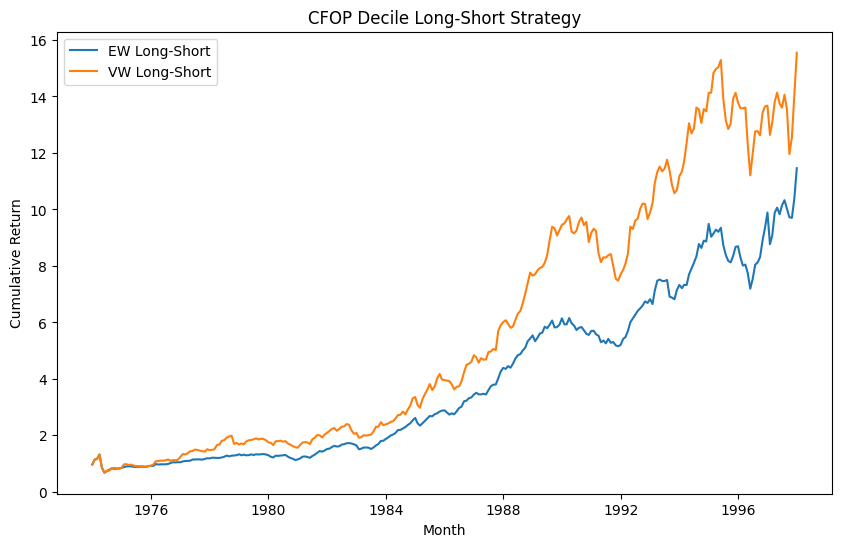

In [67]:
ew_cum = (1 + ew_cfop["long_short"].fillna(0)).cumprod()
vw_cum = (1 + vw_cfop["long_short"].fillna(0)).cumprod()

plt.figure(figsize=(10,6))
plt.plot(ew_cum.index, ew_cum, label="EW Long-Short")
plt.plot(vw_cum.index, vw_cum, label="VW Long-Short")
plt.title("CFOP Decile Long-Short Strategy")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

**Decile average return table**

In [68]:
ew_mean = ew_cfop.mean().round(4)
vw_mean = vw_cfop.mean().round(4)

In [69]:
decile_table_cfota = pd.DataFrame({
    "EW_Return": ew_mean,
    "VW_Return": vw_mean
}).round(4)

decile_table_cfota

,EW_Return,VW_Return
port,,
1.0,0.0119,0.0065
2.0,0.0082,0.0041
3.0,0.0109,0.0086
4.0,0.0140,0.0123
5.0,0.0147,0.0131
6.0,0.0170,0.0137
7.0,0.0177,0.0158
8.0,0.0181,0.0145
9.0,0.0199,0.0157


Equal-weighted deciles

Monthly Return:
- D1: 1.19%
- D10: 2.13%

Long-Short:
- D10 − D1 = 0.94% per month
- Annualized ≈ 11.26% per year

Returns increase almost monotonically from D1 → D10. Firms with higher CFO/P ratios earn higher subsequent returns. That confirms the cash-flow anomaly.

Value-weighted deciles

Monthly Return:
- D1: 0.65%
- D10: 1.74%

Long-short:
- D10 − D1 = 1.09% per month
- Annualized ≈ 13.05%

The anomaly is even stronger in value-weighted portfolios, which suggests: It is not driven only by small firms.



**Statistical significance**

In [70]:
def perf_stats(series):

    s = series.dropna()

    mean = s.mean()
    vol = s.std()

    tstat = mean / (vol / np.sqrt(len(s)))

    ann_return = mean * 12
    ann_vol = vol * np.sqrt(12)

    return pd.Series({
        "mean_monthly": mean,
        "t_stat": tstat,
        "ann_return": ann_return,
        "ann_vol": ann_vol
    })

print("\nEW long-short stats")
print(perf_stats(ew_cfop["long_short"]))

print("\nVW long-short stats")
print(perf_stats(vw_cfop["long_short"]))


EW long-short stats
mean_monthly    0.009384
t_stat          3.893944
ann_return      0.112608
ann_vol         0.141918
dtype: float64

VW long-short stats
mean_monthly    0.010875
t_stat          3.668129
ann_return      0.130497
ann_vol         0.174588
dtype: float64


Typical significance thresholds:
- t > 2  → significant
- t > 3  → strong

Our result:
- t ≈ 3.7 – 3.9

Very strong evidence.

**Plot the decile ladder**

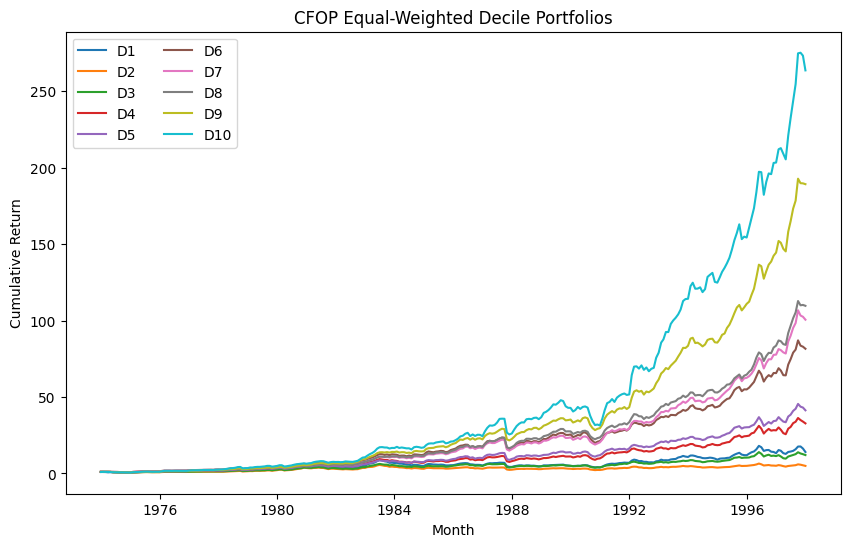

In [71]:
plt.figure(figsize=(10,6))

for p in range(1,11):
    plt.plot((1 + ew_cfop[p].fillna(0)).cumprod(), label=f"D{p}")

plt.title("CFOP Equal-Weighted Decile Portfolios")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2)
plt.show()

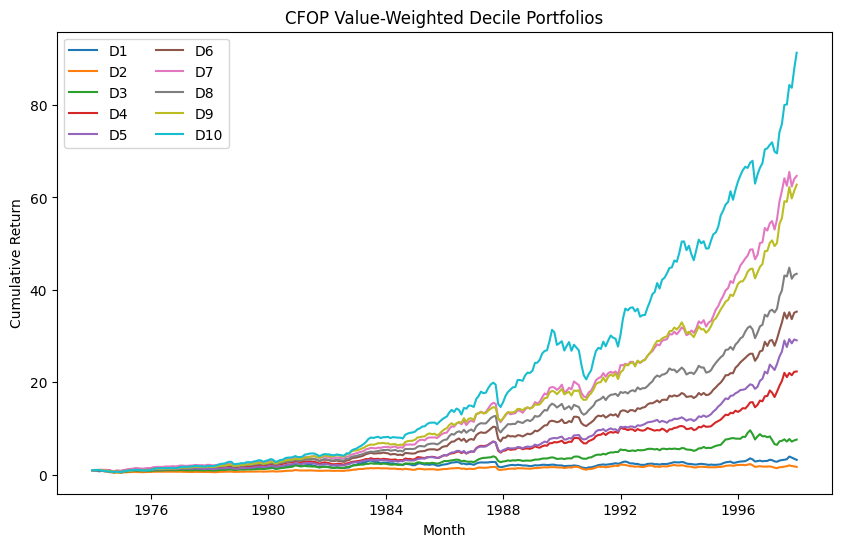

In [72]:
plt.figure(figsize=(10,6))

for p in range(1,11):
    plt.plot((1 + vw_cfop[p].fillna(0)).cumprod(), label=f"D{p}")

plt.title("CFOP Value-Weighted Decile Portfolios")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2)
plt.show()

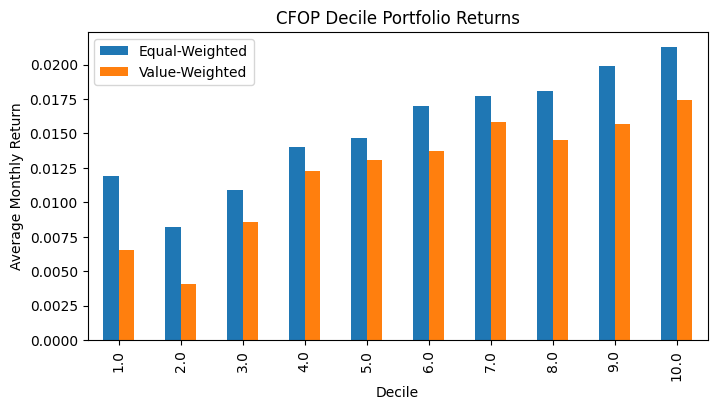

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine EW and VW decile means
plot_df = pd.DataFrame({
    "Equal-Weighted": ew_mean.drop("long_short"),
    "Value-Weighted": vw_mean.drop("long_short")
})

# Plot
plot_df.plot(kind="bar", figsize=(8,4))

plt.title("CFOP Decile Portfolio Returns")
plt.ylabel("Average Monthly Return")
plt.xlabel("Decile")
plt.legend()
plt.show()

The decile portfolio results reveal a strong monotonic relationship between the CFOP signal and subsequent returns. Firms in the highest CFOP decile earn an average monthly return of 2.13% in equal-weighted portfolios compared to 1.19% for the lowest decile. The long-short strategy (D10 − D1) produces a monthly return of approximately 0.94%, corresponding to an annualized return of 11.3%. The strategy remains economically and statistically significant in value-weighted portfolios, generating 1.09% per month with a t-statistic of 3.67. These results indicate that the CFOP signal captures meaningful cross-sectional variation in expected returns.

**2. Build CFO/TA sort portfolios by month: Deciles, 10 portfolios**

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# signal and number of portfolios
sort_var = "cfo_ta"
nport = 10

cfota_bt = bt_panel.copy()

# keep usable rows
cfota_bt = cfota_bt.dropna(subset=[sort_var, "retadj"]).copy()

# assign monthly deciles
cfota_bt["port"] = cfota_bt.groupby("hold_month")[sort_var].transform(
    lambda x: pd.qcut(x, nport, labels=False, duplicates="drop") + 1
)

print(cfota_bt[["permno", "hold_month", sort_var, "port"]].head())
print(cfota_bt["port"].value_counts().sort_index())

**Equal-weighted decile returns**

In [75]:
# Equal-weighted decile returns
ew_cfota = (
    cfota_bt.groupby(["hold_month", "port"])["retadj"]
    .mean()
    .reset_index()
    .pivot(index="hold_month", columns="port", values="retadj")
    .sort_index()
)

ew_cfota

port,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
hold_month,,,,,,,,,,
1973-12-31,-0.081081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.047619
1974-01-31,0.129412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.057143
1974-02-28,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012424
1974-03-31,-0.052632,NaN,NaN,-0.192308,NaN,NaN,0.025974,NaN,NaN,0.046154
1974-04-30,-0.111111,NaN,NaN,NaN,0.238095,NaN,NaN,NaN,NaN,-0.088235
...,...,...,...,...,...,...,...,...,...,...
1997-08-31,0.062934,0.058849,0.054299,0.036807,0.027128,0.023579,0.033764,0.037286,0.026045,0.035084
1997-09-30,0.117920,0.105609,0.086694,0.081600,0.085045,0.074705,0.074697,0.074856,0.066038,0.075598
1997-10-31,-0.014585,-0.035473,-0.036494,-0.025400,-0.027512,-0.029836,-0.027326,-0.025388,-0.030574,-0.025402


**Value-weighted decile returns**

In [76]:
# Value-weighted decile returns
cfota_bt_vw = cfota_bt.dropna(subset=["me_lag"]).copy()

vw_cfota = (
    cfota_bt_vw.groupby(["hold_month", "port"])
    .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
    .reset_index(name="retadj")
    .pivot(index="hold_month", columns="port", values="retadj")
    .sort_index()
)

vw_cfota

/tmp/ipykernel_3538/4114147591.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))


port,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
hold_month,,,,,,,,,,
1973-12-31,-0.081081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.047619
1974-01-31,0.129412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.057143
1974-02-28,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012424
1974-03-31,-0.052632,NaN,NaN,-0.192308,NaN,NaN,0.025974,NaN,NaN,0.046154
1974-04-30,-0.111111,NaN,NaN,NaN,0.238095,NaN,NaN,NaN,NaN,-0.088235
...,...,...,...,...,...,...,...,...,...,...
1997-08-31,0.030281,0.056748,0.049648,0.019437,0.014807,-0.045402,-0.053543,-0.048186,-0.032604,-0.014689
1997-09-30,0.164431,0.118314,0.065573,0.071879,0.051506,0.054117,0.052909,0.047604,0.046973,0.032253
1997-10-31,-0.072416,-0.078480,-0.047259,-0.063726,-0.040501,-0.040633,-0.029998,-0.025787,-0.043488,-0.036143


**Long-short returns: D10 - D1**

In [77]:
# Long-short returns: D10 - D1
ew_cfota["long_short"] = ew_cfota[10] - ew_cfota[1]
vw_cfota["long_short"] = vw_cfota[10] - vw_cfota[1]

print("EW monthly mean:", ew_cfota["long_short"].mean())
print("VW monthly mean:", vw_cfota["long_short"].mean())

EW monthly mean: 0.007734774296402514
VW monthly mean: 0.009527172880717584


**Cumulative performance**

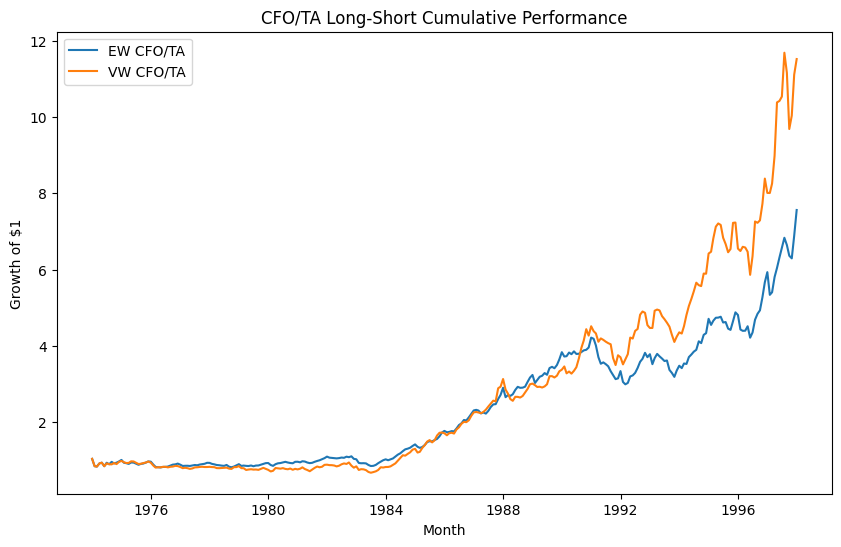

In [78]:
ew_cum_cfota = (1 + ew_cfota["long_short"].fillna(0)).cumprod()
vw_cum_cfota = (1 + vw_cfota["long_short"].fillna(0)).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(ew_cum_cfota.index, ew_cum_cfota, label="EW CFO/TA")
plt.plot(vw_cum_cfota.index, vw_cum_cfota, label="VW CFO/TA")
plt.title("CFO/TA Long-Short Cumulative Performance")
plt.xlabel("Month")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

**Decile average return table**

In [79]:
# Average return of each decile across time
ew_cfota_mean = ew_cfota.mean().round(4)
vw_cfota_mean = vw_cfota.mean().round(4)

In [80]:
decile_table_cfota = pd.DataFrame({
    "EW_Return": ew_cfota_mean,
    "VW_Return": vw_cfota_mean
}).round(4)

decile_table_cfota

,EW_Return,VW_Return
port,,
1.0,0.0099,0.0043
2.0,0.0125,0.0099
3.0,0.0134,0.0108
4.0,0.0148,0.0094
5.0,0.0164,0.0118
6.0,0.0168,0.0117
7.0,0.0176,0.0126
8.0,0.0177,0.0120
9.0,0.0171,0.0136


**Statistical significance**

In [81]:
print("\nEW long-short stats")
print(perf_stats(ew_cfota["long_short"]))

print("\nVW long-short stats")
print(perf_stats(vw_cfota["long_short"]))


EW long-short stats
mean_monthly    0.007735
t_stat          3.511733
ann_return      0.092817
ann_vol         0.129708
dtype: float64

VW long-short stats
mean_monthly    0.009527
t_stat          3.555346
ann_return      0.114326
ann_vol         0.157805
dtype: float64


**Plot the decile ladder**

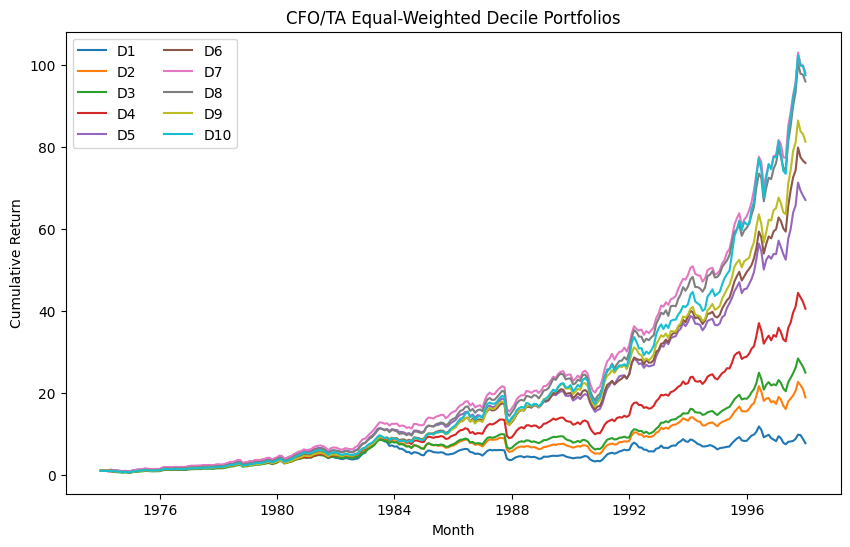

In [82]:
plt.figure(figsize=(10,6))

for p in range(1,11):
    plt.plot((1 + ew_cfota[p].fillna(0)).cumprod(), label=f"D{p}")

plt.title("CFO/TA Equal-Weighted Decile Portfolios")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2)
plt.show()

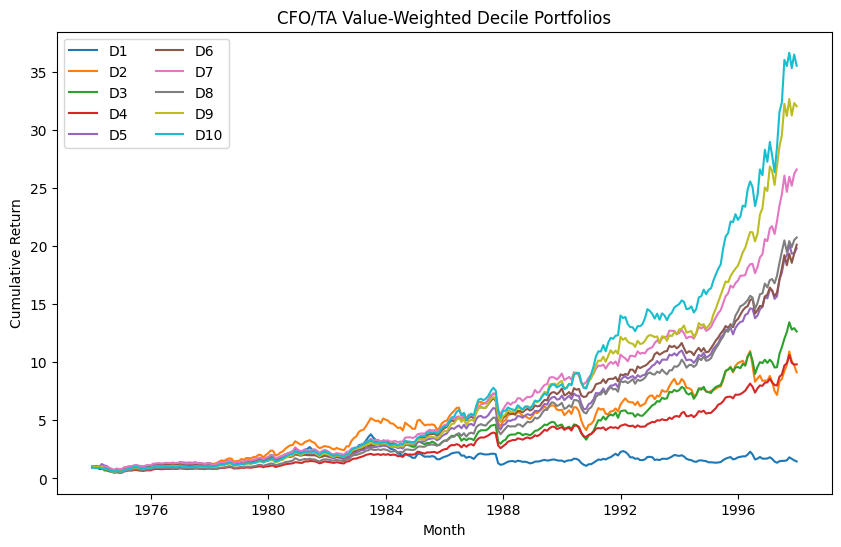

In [83]:
plt.figure(figsize=(10,6))

for p in range(1,11):
    plt.plot((1 + vw_cfota[p].fillna(0)).cumprod(), label=f"D{p}")

plt.title("CFO/TA Value-Weighted Decile Portfolios")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2)
plt.show()

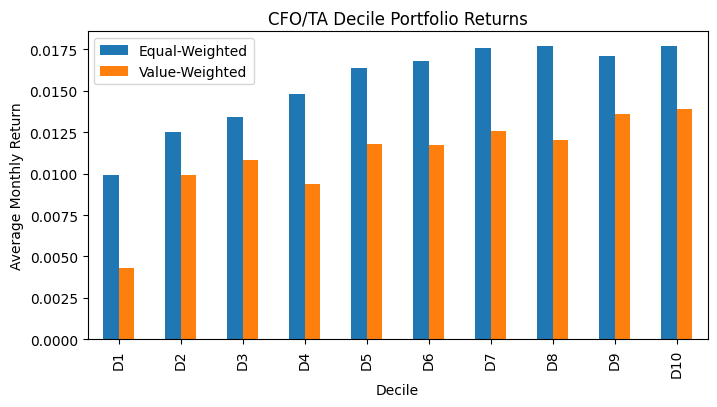

In [84]:
plot_df_cfota = pd.DataFrame({
    "Equal-Weighted": ew_cfota_mean.drop("long_short"),
    "Value-Weighted": vw_cfota_mean.drop("long_short")
})

plot_df_cfota.index = [f"D{i}" for i in range(1,11)]

plot_df_cfota.plot(kind="bar", figsize=(8,4))

plt.title("CFO/TA Decile Portfolio Returns")
plt.ylabel("Average Monthly Return")
plt.xlabel("Decile")
plt.show()

## All signals:

**Long Short Portfolio (EW and VW) return and t-stat on each signal**

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

signals_to_test = ["cfop","cfo_ta", "acc", "bm", "sg", "ep"]

all_results = []

for s in signals_to_test:
    tmp = bt_panel.dropna(subset=[s, "retadj"]).copy()

    # monthly deciles
    tmp["port"] = tmp.groupby("hold_month")[s].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1
    )

    # equal-weighted returns
    ew = (
        tmp.groupby(["hold_month", "port"])["retadj"]
        .mean()
        .reset_index()
        .pivot(index="hold_month", columns="port", values="retadj")
        .sort_index()
    )

    # value-weighted returns
    tmp_vw = tmp.dropna(subset=["me_lag"]).copy()
    vw = (
        tmp_vw.groupby(["hold_month", "port"])
        .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
        .reset_index(name="retadj")
        .pivot(index="hold_month", columns="port", values="retadj")
        .sort_index()
    )

    # long-short
    ew["ls"] = ew[10] - ew[1]
    vw["ls"] = vw[10] - vw[1]

    # stats helper
    def tstat(series):
        x = series.dropna()
        return x.mean() / (x.std() / np.sqrt(len(x))) if len(x) > 1 and x.std() != 0 else np.nan

    all_results.append({
        "signal": s,
        "ew_mean_monthly": ew["ls"].mean(),
        "ew_ann_return": ew["ls"].mean() * 12,
        "ew_tstat": tstat(ew["ls"]),
        "vw_mean_monthly": vw["ls"].mean(),
        "vw_ann_return": vw["ls"].mean() * 12,
        "vw_tstat": tstat(vw["ls"]),
    })

results_df = pd.DataFrame(all_results).sort_values("vw_mean_monthly", ascending=False)
results_df

/tmp/ipykernel_3538/2124045755.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
/tmp/ipykernel_3538/2124045755.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
/tmp/ipykernel_3538/2124045755.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. T

,signal,ew_mean_monthly,ew_ann_return,ew_tstat,vw_mean_monthly,vw_ann_return,vw_tstat
5,ep,0.003836,0.046036,1.498722,0.012011,0.144137,3.623384
0,cfop,0.009384,0.112608,3.893944,0.010875,0.130497,3.668129
1,cfo_ta,0.007735,0.092817,3.511733,0.009527,0.114326,3.555346
3,bm,0.012727,0.152720,5.026237,0.006343,0.076119,1.987296
4,sg,-0.011146,-0.133749,-4.557528,-0.002928,-0.035141,-1.011729
2,acc,-0.010062,-0.120746,-4.806488,-0.007595,-0.091135,-2.867123


**Plot of Long-Short Avg Monthly Returns by Signal**

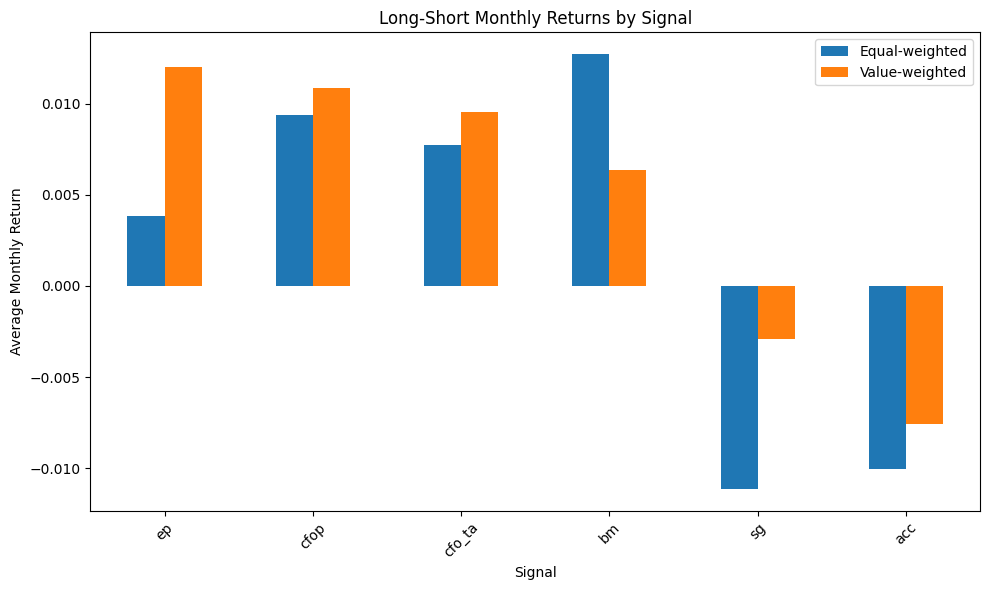

In [86]:
plot_df = results_df.set_index("signal")[["ew_mean_monthly", "vw_mean_monthly"]]

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Long-Short Monthly Returns by Signal")
plt.ylabel("Average Monthly Return")
plt.xlabel("Signal")
plt.xticks(rotation=45)
plt.legend(["Equal-weighted", "Value-weighted"])
plt.tight_layout()
plt.show()

## Factor-adjusted alpha regressions: CFO/P and CFO/TA

In [87]:
ff = db.raw_sql("""
    select
        date,
        mktrf,
        smb,
        hml,
        rf
    from ff.factors_monthly
    where date >= '1973-01-01'
      and date <= '1997-12-31'
""", date_cols=["date"])

ff.head()

,date,mktrf,smb,hml,rf
0,1973-01-01,-0.0327,-0.0349,0.027,0.0044
1,1973-02-01,-0.0485,-0.0389,0.0164,0.0042
2,1973-03-01,-0.013,-0.0278,0.0257,0.0046
3,1973-04-01,-0.0568,-0.0384,0.0539,0.0052
4,1973-05-01,-0.0297,-0.0627,0.0038,0.0051


In [88]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -------------------------
# 1. Prepare FF factors
# -------------------------
ff = ff.copy()

ff["date"] = pd.to_datetime(ff["date"])
ff["date"] = ff["date"] + pd.offsets.MonthEnd(0)   # align to month-end

# ensure numeric
ff[["mktrf","smb","hml","rf"]] = ff[["mktrf","smb","hml","rf"]].astype(float)

ff.head()

,date,mktrf,smb,hml,rf
0,1973-01-31,-0.0327,-0.0349,0.0270,0.0044
1,1973-02-28,-0.0485,-0.0389,0.0164,0.0042
2,1973-03-31,-0.0130,-0.0278,0.0257,0.0046
3,1973-04-30,-0.0568,-0.0384,0.0539,0.0052
4,1973-05-31,-0.0297,-0.0627,0.0038,0.0051


In [89]:
# Prepare long-short returns:
# -----------------------------
# CFOP long-short
# -----------------------------
ls_cfop_ew = ew_cfop["long_short"].reset_index()
ls_cfop_ew.columns = ["date", "cfop_ls_ew"]

ls_cfop_vw = vw_cfop["long_short"].reset_index()
ls_cfop_vw.columns = ["date", "cfop_ls_vw"]

# -----------------------------
# CFO/TA long-short
# -----------------------------
ls_cfota_ew = ew_cfota["long_short"].reset_index()
ls_cfota_ew.columns = ["date", "cfota_ls_ew"]

ls_cfota_vw = vw_cfota["long_short"].reset_index()
ls_cfota_vw.columns = ["date", "cfota_ls_vw"]

# -----------------------------
# Align dates to month-end
# -----------------------------
for df in [ls_cfop_ew, ls_cfop_vw, ls_cfota_ew, ls_cfota_vw]:
    df["date"] = pd.to_datetime(df["date"]) + pd.offsets.MonthEnd(0)

# -----------------------------
# Merge into one dataframe
# -----------------------------
ls_all = (
    ls_cfop_ew
    .merge(ls_cfop_vw, on="date", how="inner")
    .merge(ls_cfota_ew, on="date", how="inner")
    .merge(ls_cfota_vw, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

ls_all.head()

,date,cfop_ls_ew,cfop_ls_vw,cfota_ls_ew,cfota_ls_vw
0,1973-12-31,-0.033462,-0.033462,0.033462,0.033462
1,1974-01-31,0.186555,0.186555,-0.186555,-0.186555
2,1974-02-28,0.012424,0.012424,-0.012424,-0.012424
3,1974-03-31,0.139676,0.139676,0.098786,0.098786
4,1974-04-30,-0.349206,-0.349206,0.022876,0.022876


In [90]:
# Merge long-short returns with Fama-French factors
reg_df = ls_all.merge(ff, on="date", how="inner")

print("Merged shape:", reg_df.shape)
reg_df.head()

Merged shape: (289, 9)


,date,cfop_ls_ew,cfop_ls_vw,cfota_ls_ew,cfota_ls_vw,mktrf,smb,hml,rf
0,1973-12-31,-0.033462,-0.033462,0.033462,0.033462,0.0059,-0.0540,0.0401,0.0064
1,1974-01-31,0.186555,0.186555,-0.186555,-0.186555,-0.0016,0.0968,0.0595,0.0063
2,1974-02-28,0.012424,0.012424,-0.012424,-0.012424,-0.0046,0.0000,0.0247,0.0058
3,1974-03-31,0.139676,0.139676,0.098786,0.098786,-0.0282,0.0250,-0.0014,0.0056
4,1974-04-30,-0.349206,-0.349206,0.022876,0.022876,-0.0528,-0.0068,0.0092,0.0075


In [91]:
# Compute excess returns
for col in ["cfop_ls_ew","cfop_ls_vw","cfota_ls_ew","cfota_ls_vw"]:
    reg_df[f"{col}_excess"] = reg_df[col] - reg_df["rf"]

**Key Risk Adjusted Metrics:**

In [92]:
def performance_metrics(returns, rf):

    df = pd.DataFrame({
        "ret": returns,
        "rf": rf
    }).dropna()

    r = df["ret"]
    excess = df["ret"] - df["rf"]

    mean_m = r.mean()
    vol_m = r.std()

    ann_return = mean_m * 12
    ann_vol = vol_m * np.sqrt(12)

    # Correct Sharpe ratio using excess returns
    sharpe = (excess.mean() / excess.std()) * np.sqrt(12)

    t_stat = mean_m / (vol_m / np.sqrt(len(r)))

    max_drawdown = ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()

    best_month = r.max()
    worst_month = r.min()

    hit_rate = (r > 0).mean()

    return {
        "n_months": len(r),
        "mean_monthly": mean_m,
        "vol_monthly": vol_m,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "t_stat": t_stat,
        "max_drawdown": max_drawdown,
        "best_month": best_month,
        "worst_month": worst_month,
        "hit_rate": hit_rate
    }

In [93]:
strategy_df = reg_df[[
    "date",
    "cfop_ls_ew",
    "cfop_ls_vw",
    "cfota_ls_ew",
    "cfota_ls_vw",
    "rf"
]]

metrics = []

strategies = [
    "cfop_ls_ew",
    "cfop_ls_vw",
    "cfota_ls_ew",
    "cfota_ls_vw"
]

for s in strategies:

    stats = performance_metrics(strategy_df[s], strategy_df["rf"])
    stats["strategy"] = s

    metrics.append(stats)

metrics_df = pd.DataFrame(metrics)

metrics_df = metrics_df.set_index("strategy").round(4)

metrics_df

,n_months,mean_monthly,vol_monthly,ann_return,ann_vol,sharpe,t_stat,max_drawdown,best_month,worst_month,hit_rate
strategy,,,,,,,,,,,
cfop_ls_ew,289,0.0094,0.0410,0.1126,0.1419,0.3091,3.8939,-0.4875,0.1866,-0.3492,0.6644
cfop_ls_vw,289,0.0109,0.0504,0.1305,0.1746,0.3538,3.6681,-0.4875,0.1866,-0.3492,0.6505
cfota_ls_ew,289,0.0077,0.0374,0.0928,0.1297,0.1866,3.5117,-0.2908,0.1090,-0.1866,0.6263
cfota_ls_vw,289,0.0095,0.0456,0.1143,0.1578,0.2896,3.5553,-0.3524,0.1561,-0.1866,0.5779


**Cumulative risk-adjusted performance**

In [94]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

strategies = ["cfop_ls_ew", "cfop_ls_vw", "cfota_ls_ew", "cfota_ls_vw"]

alpha_series_df = reg_df[["date"]].copy()
alpha_summary = []

for s in strategies:
    temp = reg_df[["date", s, "mktrf", "smb", "hml", "rf"]].dropna().copy()

    # excess return
    temp["excess_ret"] = temp[s] - temp["rf"]

    # FF3 regression
    X = sm.add_constant(temp[["mktrf", "smb", "hml"]].astype(float))
    y = temp["excess_ret"].astype(float)

    model = sm.OLS(y, X).fit()

    # monthly risk-adjusted return = alpha + residual
    temp[f"{s}_alpha_ret"] = model.params["const"] + model.resid

    # cumulative risk-adjusted performance
    temp[f"{s}_alpha_cum"] = (1 + temp[f"{s}_alpha_ret"]).cumprod()

    # save monthly alpha return series
    alpha_series_df = alpha_series_df.merge(
        temp[["date", f"{s}_alpha_ret", f"{s}_alpha_cum"]],
        on="date",
        how="left"
    )

    alpha_summary.append({
        "strategy": s,
        "alpha_monthly": model.params["const"],
        "alpha_annual": model.params["const"] * 12,
        "alpha_tstat": model.tvalues["const"],
        "r2": model.rsquared
    })

alpha_summary_df = pd.DataFrame(alpha_summary).round(4)

alpha_series_df.head()

,date,cfop_ls_ew_alpha_ret,cfop_ls_ew_alpha_cum,cfop_ls_vw_alpha_ret,cfop_ls_vw_alpha_cum,cfota_ls_ew_alpha_ret,cfota_ls_ew_alpha_cum,cfota_ls_vw_alpha_ret,cfota_ls_vw_alpha_cum
0,1973-12-31,-0.068211,0.931789,-0.087290,0.912710,0.001668,1.001668,-0.026381,0.973619
1,1974-01-31,0.161839,1.082589,0.139835,1.040339,-0.113567,0.887912,-0.098275,0.877937
2,1974-02-28,-0.006084,1.076003,-0.016151,1.023536,-0.012020,0.877240,-0.019397,0.860907
3,1974-03-31,0.139462,1.226064,0.143066,1.169969,0.108744,0.972635,0.113771,0.958853
4,1974-04-30,-0.359823,0.784898,-0.359730,0.749095,0.012013,0.984319,0.000530,0.959361


In [95]:
alpha_summary_df

,strategy,alpha_monthly,alpha_annual,alpha_tstat,r2
0,cfop_ls_ew,0.0011,0.0126,0.4395,0.1124
1,cfop_ls_vw,0.0000,0.0001,0.0015,0.2234
2,cfota_ls_ew,0.0049,0.0588,2.4465,0.2534
3,cfota_ls_vw,0.0069,0.0832,3.2094,0.4147


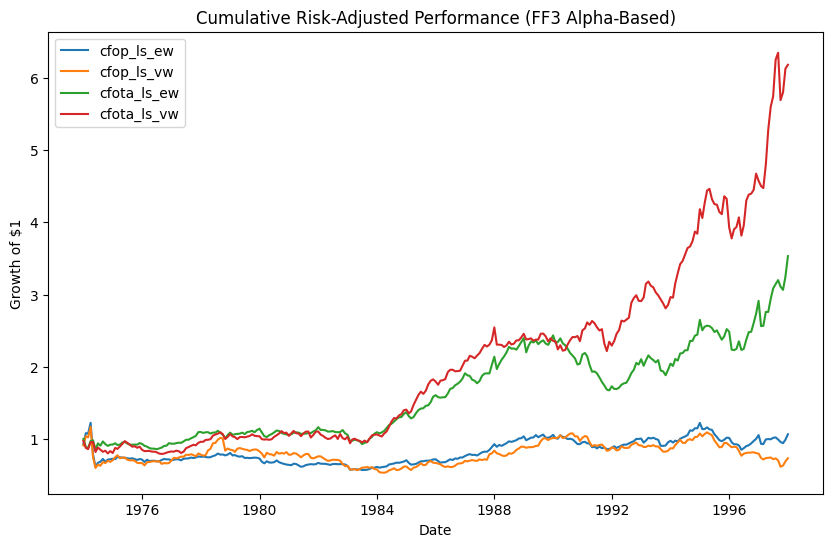

In [96]:
plt.figure(figsize=(10, 6))

for s in strategies:
    plt.plot(
        alpha_series_df["date"],
        alpha_series_df[f"{s}_alpha_cum"],
        label=s
    )

plt.title("Cumulative Risk-Adjusted Performance (FF3 Alpha-Based)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [97]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -----------------------------
# 1) Prepare FF factors
# -----------------------------
ff_reg = ff.copy()

ff_reg["date"] = pd.to_datetime(ff_reg["date"]) + pd.offsets.MonthEnd(0)

for c in ["mktrf", "smb", "hml", "rf"]:
    ff_reg[c] = pd.to_numeric(ff_reg[c], errors="coerce")

ff_reg = ff_reg.dropna(subset=["date", "mktrf", "smb", "hml", "rf"]).copy()

# -----------------------------
# 2) Signals to test
# -----------------------------
signals_to_test = ["cfop", "acc", "bm", "sg", "ep", "cfo_ta"]

# if you want only signals currently working well, use:
# signals_to_test = ["cfop", "bm", "sg", "ep", "cfo_ta"]

# -----------------------------
# 3) Helper functions
# -----------------------------
def make_long_short(df, signal, value_weighted=False, nport=10):
    """
    Builds monthly decile long-short returns for a signal.
    Long = D10, Short = D1
    """
    cols_needed = ["permno", "hold_month", signal, "retadj"]
    if value_weighted:
        cols_needed.append("me_lag")

    tmp = df[cols_needed].copy()
    tmp = tmp.dropna(subset=[signal, "retadj"])

    if value_weighted:
        tmp = tmp.dropna(subset=["me_lag"])

    # assign monthly deciles
    tmp["port"] = tmp.groupby("hold_month")[signal].transform(
        lambda x: pd.qcut(x, nport, labels=False, duplicates="drop") + 1
    )

    # keep only rows where a valid portfolio was assigned
    tmp = tmp.dropna(subset=["port"]).copy()
    tmp["port"] = tmp["port"].astype(int)

    if value_weighted:
        port_ret = (
            tmp.groupby(["hold_month", "port"])
            .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
            .reset_index(name="retadj")
            .pivot(index="hold_month", columns="port", values="retadj")
            .sort_index()
        )
    else:
        port_ret = (
            tmp.groupby(["hold_month", "port"])["retadj"]
            .mean()
            .reset_index()
            .pivot(index="hold_month", columns="port", values="retadj")
            .sort_index()
        )

    # need both D1 and D10 present
    if 1 not in port_ret.columns or 10 not in port_ret.columns:
        return pd.DataFrame(columns=["date", "ls_ret"])

    ls = (port_ret[10] - port_ret[1]).reset_index()
    ls.columns = ["date", "ls_ret"]
    ls["date"] = pd.to_datetime(ls["date"]) + pd.offsets.MonthEnd(0)

    return ls


def run_ff3(ls_df, ff_df):
    """
    Runs FF3 regression on long-short returns.
    """
    reg = ls_df.merge(ff_df, on="date", how="inner").copy()

    for c in ["ls_ret", "mktrf", "smb", "hml", "rf"]:
        reg[c] = pd.to_numeric(reg[c], errors="coerce")

    reg = reg.dropna(subset=["ls_ret", "mktrf", "smb", "hml", "rf"]).copy()

    if reg.empty:
        return None

    reg["excess_ret"] = reg["ls_ret"] - reg["rf"]

    X = reg[["mktrf", "smb", "hml"]].astype(float)
    X = sm.add_constant(X)
    y = reg["excess_ret"].astype(float)

    model = sm.OLS(y, X).fit()

    return {
        "n_months": len(reg),
        "mean_monthly_ls": reg["ls_ret"].mean(),
        "alpha_monthly": model.params["const"],
        "alpha_annual": model.params["const"] * 12,
        "alpha_tstat": model.tvalues["const"],
        "beta_mktrf": model.params["mktrf"],
        "beta_smb": model.params["smb"],
        "beta_hml": model.params["hml"],
        "r2": model.rsquared,
        "model": model
    }

# -----------------------------
# 4) Run for all signals
# -----------------------------
ff3_results = []

for sig in signals_to_test:
    # Equal-weighted long-short
    ls_ew = make_long_short(bt_panel, sig, value_weighted=False, nport=10)
    ew_out = run_ff3(ls_ew, ff_reg)

    # Value-weighted long-short
    ls_vw = make_long_short(bt_panel, sig, value_weighted=True, nport=10)
    vw_out = run_ff3(ls_vw, ff_reg)

    row = {
        "signal": sig,

        "ew_n_months": ew_out["n_months"] if ew_out else np.nan,
        "ew_mean_monthly_ls": ew_out["mean_monthly_ls"] if ew_out else np.nan,
        "ew_alpha_monthly": ew_out["alpha_monthly"] if ew_out else np.nan,
        "ew_alpha_annual": ew_out["alpha_annual"] if ew_out else np.nan,
        "ew_alpha_tstat": ew_out["alpha_tstat"] if ew_out else np.nan,
        "ew_beta_mktrf": ew_out["beta_mktrf"] if ew_out else np.nan,
        "ew_beta_smb": ew_out["beta_smb"] if ew_out else np.nan,
        "ew_beta_hml": ew_out["beta_hml"] if ew_out else np.nan,
        "ew_r2": ew_out["r2"] if ew_out else np.nan,

        "vw_n_months": vw_out["n_months"] if vw_out else np.nan,
        "vw_mean_monthly_ls": vw_out["mean_monthly_ls"] if vw_out else np.nan,
        "vw_alpha_monthly": vw_out["alpha_monthly"] if vw_out else np.nan,
        "vw_alpha_annual": vw_out["alpha_annual"] if vw_out else np.nan,
        "vw_alpha_tstat": vw_out["alpha_tstat"] if vw_out else np.nan,
        "vw_beta_mktrf": vw_out["beta_mktrf"] if vw_out else np.nan,
        "vw_beta_smb": vw_out["beta_smb"] if vw_out else np.nan,
        "vw_beta_hml": vw_out["beta_hml"] if vw_out else np.nan,
        "vw_r2": vw_out["r2"] if vw_out else np.nan,
    }

    ff3_results.append(row)

ff3_table = pd.DataFrame(ff3_results)

# round for display
display_cols = [
    "signal",
    "ew_n_months", "ew_mean_monthly_ls", "ew_alpha_monthly", "ew_alpha_annual", "ew_alpha_tstat", "ew_r2",
    "vw_n_months", "vw_mean_monthly_ls", "vw_alpha_monthly", "vw_alpha_annual", "vw_alpha_tstat", "vw_r2"
]

ff3_table[display_cols].round(4)

/tmp/ipykernel_3538/3118341098.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
/tmp/ipykernel_3538/3118341098.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["retadj"], weights=x["me_lag"]))
/tmp/ipykernel_3538/3118341098.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. T

,signal,ew_n_months,ew_mean_monthly_ls,ew_alpha_monthly,ew_alpha_annual,ew_alpha_tstat,ew_r2,vw_n_months,vw_mean_monthly_ls,vw_alpha_monthly,vw_alpha_annual,vw_alpha_tstat,vw_r2
0,cfop,289,0.0094,0.0011,0.0126,0.4395,0.1124,289,0.0108,-0.0000,-0.0004,-0.0129,0.2243
1,acc,289,-0.0101,-0.0151,-0.1812,-7.1595,0.0749,289,-0.0076,-0.0135,-0.1616,-5.1104,0.1088
2,bm,289,0.0127,0.0019,0.0232,1.0446,0.5254,289,0.0063,-0.0092,-0.1103,-4.4026,0.6163
3,sg,289,-0.0111,-0.0128,-0.1539,-5.9712,0.3029,289,-0.0029,-0.0041,-0.0488,-1.5818,0.2904
4,ep,289,0.0038,-0.0025,-0.0297,-0.9671,0.0925,289,0.0120,0.0024,0.0289,0.7388,0.1238
5,cfo_ta,289,0.0077,0.0049,0.0588,2.4465,0.2534,289,0.0095,0.0069,0.0824,3.1817,0.4158


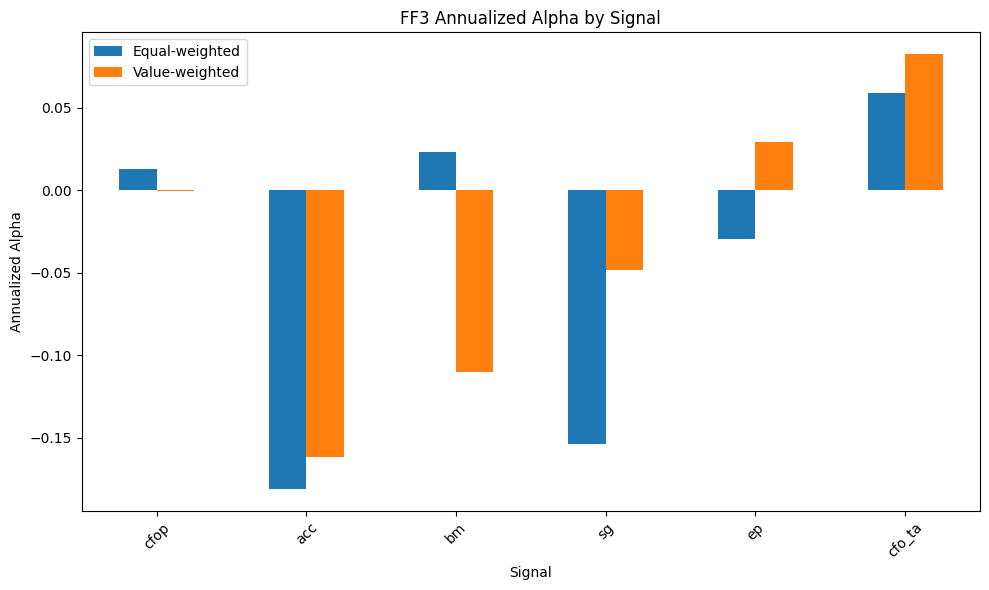

In [98]:
import matplotlib.pyplot as plt

plot_df = ff3_table.set_index("signal")[["ew_alpha_annual", "vw_alpha_annual"]]

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("FF3 Annualized Alpha by Signal")
plt.ylabel("Annualized Alpha")
plt.xlabel("Signal")
plt.xticks(rotation=45)
plt.legend(["Equal-weighted", "Value-weighted"])
plt.tight_layout()
plt.show()

## Signal-by-Signal Interpretation


**1. CFOP (Cash Flow to Price)**

Raw portfolio results
- EW long-short return: 0.94% per month
- VW long-short return: 1.08% per month

Annualized:
- EW: 11.3%
- VW: 13.0%

These results indicate that firms with higher cash flow relative to price earn higher subsequent returns, which is consistent with the intuition that firms generating strong cash flows relative to their valuation are undervalued.

Factor-adjusted results

After controlling for Fama-French factors:

- EW alpha: 0.10% per month (1.26% annually)

- t-stat: 0.44

- VW alpha: approximately 0

- t-stat: −0.02

Interpretation

Although CFOP generates economically large raw returns, the abnormal performance disappears once exposures to market, size, and value factors are controlled for. This suggests that the CFOP strategy primarily loads on systematic risk factors rather than capturing independent mispricing.

**2. CFO/TA (Cash Flow to Assets)**

Raw portfolio results

- EW long-short return: 0.77% per month

- VW long-short return: 0.95% per month

Annualized:

- EW: 9.2%

- VW: 11.4%

Factor-adjusted results

- EW alpha: 0.49% per month (5.9% annually)

- t-stat: 2.45

- VW alpha: 0.69% per month (8.2% annually)

- t-stat: 3.18

Interpretation

The CFO/TA signal produces strong and statistically significant abnormal returns even after controlling for the Fama-French factors. This indicates that the signal captures information about firm profitability that is not fully incorporated into market prices.

**3. ACC (Accruals)**

Raw portfolio results

- EW long-short return: −1.01% per month

- VW long-short return: −0.76% per month

Annualized:

- EW: −12.1%

- VW: −9.1%

Factor-adjusted results

- EW alpha: −1.51% per month (−18.1% annually)

- t-stat: −7.16

- VW alpha: −1.35% per month (−16.2% annually)

- t-stat: −5.11

Interpretation

The negative sign reflects the direction of the portfolio construction. High-accrual firms tend to underperform low-accrual firms, consistent with the well-documented accrual anomaly. The large magnitude and very strong statistical significance indicate that accruals capture a powerful cross-sectional predictor of returns that is not explained by the Fama-French factors.

**4. BM (Book-to-Market)**

Raw portfolio results

- EW long-short return: 1.27% per month

- VW long-short return: 0.63% per month

Annualized:

- EW: 15.2%

- VW: 7.6%

Factor-adjusted results

- EW alpha: 0.19% per month (2.31% annually)

- t-stat: 1.04

- VW alpha: −0.92% per month (−11.0% annually)

- t-stat: −4.41

Interpretation

The book-to-market signal produces large raw returns, particularly in equal-weighted portfolios. However, once the Fama-French model is applied, the alpha largely disappears. This is expected because the HML factor already captures the value premium, meaning book-to-market strategies should not produce large abnormal returns after controlling for this factor.

5. SG (Sales Growth)

Raw portfolio results

- EW long-short return: −1.11% per month

- VW long-short return: −0.29% per month

Annualized:

- EW: −13.3%

- VW: −3.5%

Factor-adjusted results

- EW alpha: −1.28% per month (−15.4% annually)

- t-stat: −5.97

- VW alpha: −0.41% per month (−4.9% annually)

- t-stat: −1.58

Interpretation

The negative returns indicate that firms with higher past sales growth tend to underperform those with lower growth. This result is consistent with behavioral explanations where investors over-extrapolate growth trends, leading to overvaluation of high-growth firms.

6. EP (Earnings to Price)

Raw portfolio results

- EW long-short return: 0.38% per month

- VW long-short return: 1.20% per month

Annualized:

- EW: 4.6%

- VW: 14.4%

Factor-adjusted results

- EW alpha: −0.25% per month (−3.0% annually)

- t-stat: −0.97

- VW alpha: 0.24% per month (2.88% annually)

- t-stat: 0.74

Interpretation

Although earnings yield produces modest raw returns, the factor-adjusted alpha is statistically insignificant. This suggests that the predictive power of earnings yield is largely explained by common risk factors rather than representing a distinct anomaly.

**Overall Conclusions**

Across the tested signals, several patterns emerge.

First, some signals such as CFOP and book-to-market generate strong raw returns but little factor-adjusted alpha, suggesting their performance is largely driven by exposures to systematic risk factors.

Second, accruals and sales growth display strong and statistically significant abnormal returns, consistent with well-known behavioral anomalies documented in the literature.

Finally, CFO/TA appears to be the most robust signal, generating economically large and statistically significant alphas in both equal-weighted and value-weighted portfolios.